<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**

ChicStyle is a growing fashion retailer that receives large spikes in customer reviews during festive seasons and holiday sales. These reviews contain critical signals about customer experience, including fit, sizing, fabric quality, color accuracy, delivery issues, and overall satisfaction. If this feedback is not analyzed quickly, the business may miss urgent complaints, fail to respond to dissatisfied customers in time, and risk lower trust, fewer repeat purchases, and damage to brand reputation.

This problem is important because simple sentiment analysis is not enough for retail decision-making. A review may be positive about one aspect of a product and negative about another, such as praising style while criticizing fit or quality. Generative AI is useful here because it can understand the full context of a review, identify whether the feedback is about a product or service issue, summarize the concern, assign an urgency level, and translate that feedback into actionable business insights.

### **Objective**

The objective is to build a Generative AI feedback intelligence pipeline that can automatically process customer reviews and convert them into structured, actionable insights for ChicStyle. The system should:

- Analyze and categorize sentiment in real time.
- Identify the main product or service issue discussed in each review using an explicit `Feedback_Type` field.
- Assign an explicit `Urgency_Level` so support and product teams can prioritize high-impact issues.
- Summarize insights by product category, feedback type, and operational urgency.
- Generate short, personalized customer-facing messages.
- Produce concise, actionable reports for retail, merchandising, product, and customer support teams.

### **Dataset Used for the Notebook**

This notebook uses the **Women's E-Commerce Clothing Reviews** dataset. The file is saved as `.csv`, but the fields are separated with semicolons, so it is loaded with `sep=';'`. Key columns include `Clothing.ID`, `Age`, `Title`, `Review.Text`, `Rating`, `Recommended.IND`, `Positive.Feedback.Count`, `Division.Name`, `Department.Name`, and `Class.Name`.


### **Final Submission Executive Snapshot**

This final notebook presents the full-code solution for ChicStyle's real-time retail feedback intelligence problem. The strongest project findings are:

- The review data is highly positive overall, but the most valuable business signals are the recurring friction points hidden inside the text: sizing inconsistency, fit uncertainty, fabric/quality concerns, and product-image or color expectation gaps.
- The final structured output now includes **seven fields**: `Feedback_Type`, `Category`, `Sentiment`, `Urgency_Level`, `Summary`, `Personalized_Message`, and `Retail_Insight`.
- The completed baseline comparison across Zero-Shot, Few-Shot, and Chain-of-Thought prompting identified **Zero-Shot V1** as the strongest design, with **CoT V2** and **Few-Shot V1** close behind.
- The final proposed production design is a **Zero-Shot V1 primary pipeline** because it is high-performing, simple to maintain, and easy to monitor. **CoT V2** should be kept as an escalation prompt for especially mixed, ambiguous, or high-impact reviews.
- The recommendation-intent workflow reached **80.0% accuracy** on the evaluated sample and was conservative: it was strong at catching non-recommended cases, but missed some reviews that customers still recommended.
- The main implementation recommendation is to deploy the GenAI pipeline as a first-pass triage and insight layer, not as an unsupervised final decision-maker. Human review should remain in place for high-urgency complaints, low-confidence outputs, and customer-facing escalations.


### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [1]:
# Install the required libraries for the project
!pip -q install pandas matplotlib seaborn plotly wordcloud scikit-learn openai tqdm

In [58]:
# Import the required libraries for the project

# Core utilities
import time
import json
import re
import numpy as np
from typing import Dict, List, Optional, Any, Tuple

import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Data handling
import pandas as pd
from google.colab import userdata

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
from IPython.display import display

# Machine learning metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import CountVectorizer

# Progress bar
from tqdm import tqdm

# OpenAI client
import openai

# Set global plot style
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 200)

### **Data Loading**

The dataset is loaded from Google Drive. Because this file is semicolon-delimited, `sep=';'` is required even though the file extension is `.csv`.


In [3]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Import the dataset
df = pd.read_csv('/content/drive/MyDrive/MIT Data Science/Capstone/Dataset - Real-Time Retail Feedback Intelligence.csv', sep=';', index_col=0)
display(df)

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a great price! it's very easy to slip on and has a very flattering cut and color combo.,5,1,0,General Petite,Dresses,Dresses
23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stretchy, shiny material. cut is flattering and drapes nicely. i only found one button to close front... looked awkward. nice long sleeves.\r\nnot for me ...",3,1,0,General Petite,Tops,Knits
23484,1104,31,"Cute, but see through","This fit well, but the top was very see through. this never would have worked for me. i'm glad i was able to try it on in the store and didn't order it online. with different fabric, it would have...",3,0,1,General Petite,Dresses,Dresses
23485,1084,28,"Very cute dress, perfect for summer parties and we","I bought this dress for a wedding i have this summer, and it's so cute. unfortunately the fit isn't perfect. the medium fits my waist perfectly, but was way too long and too big in the bust and sh...",3,1,2,General,Dresses,Dresses


### **Data Overview**

In [5]:
# Get a summary of the dataset to check data types and non-null counts
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing.ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review.Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended.IND          23486 non-null  int64 
 6   Positive.Feedback.Count  23486 non-null  int64 
 7   Division.Name            23472 non-null  object
 8   Department.Name          23472 non-null  object
 9   Class.Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


### **Sanity checks**

In [6]:
# Check the total number of missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Clothing.ID                   0
Age                           0
Title                      3810
Review.Text                 845
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                14
Department.Name              14
Class.Name                   14
dtype: int64


### **Data Cleaning and Preprocessing**

**Think about it:** The `Review.Text` column is the most critical feature for the Generative AI model. What should be done with rows where this text is missing?  

Rows where this text is missing should be removed from the modeling dataset because the LLM cannot infer sentiment, category, summary, recommendation intent, or customer response without the actual review content. Other missing fields, such as `Title`, can be retained because they are optional metadata and are not required for the core prompt.

In [7]:
# Drop rows with no review text
df = df.dropna(subset=["Review.Text"]).copy()
df["Review.Text"] = df["Review.Text"].astype(str).str.strip()
df = df[df["Review.Text"] != ""].copy()

print("\nMissing Values after cleaning:")
print(df.isnull().sum())


Missing Values after cleaning:
Clothing.ID                   0
Age                           0
Title                      2966
Review.Text                   0
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                13
Department.Name              13
Class.Name                   13
dtype: int64


### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?

Also write your observations for each questions.

In [8]:
# Summary statistics for numerical columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Clothing.ID,22641.0,919.33,202.27,1.0,861.0,936.0,1078.0,1205.0
Age,22641.0,43.28,12.33,18.0,34.0,41.0,52.0,99.0
Rating,22641.0,4.18,1.12,1.0,4.0,5.0,5.0,5.0
Recommended.IND,22641.0,0.82,0.39,0.0,1.0,1.0,1.0,1.0
Positive.Feedback.Count,22641.0,2.63,5.79,0.0,0.0,1.0,3.0,122.0


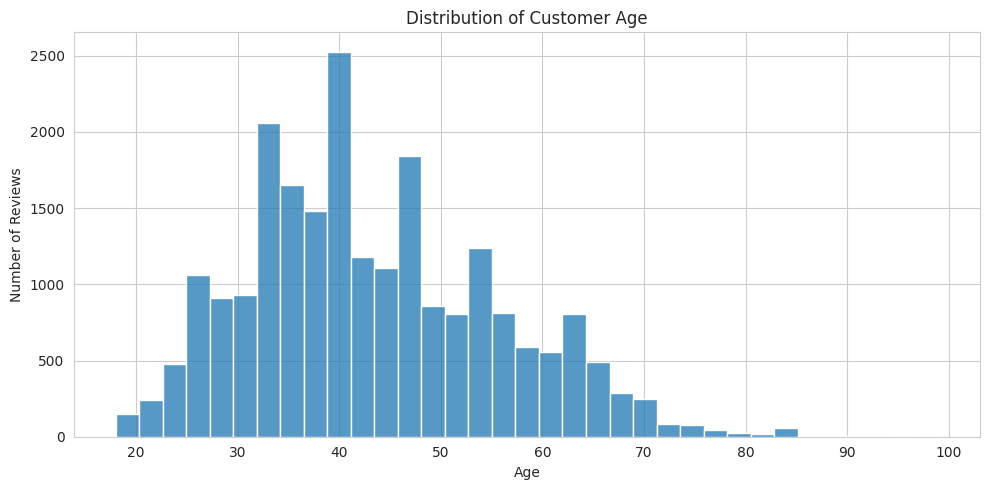

In [70]:
# Distribution plot of customer age
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Age", bins=35, edgecolor="white")
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

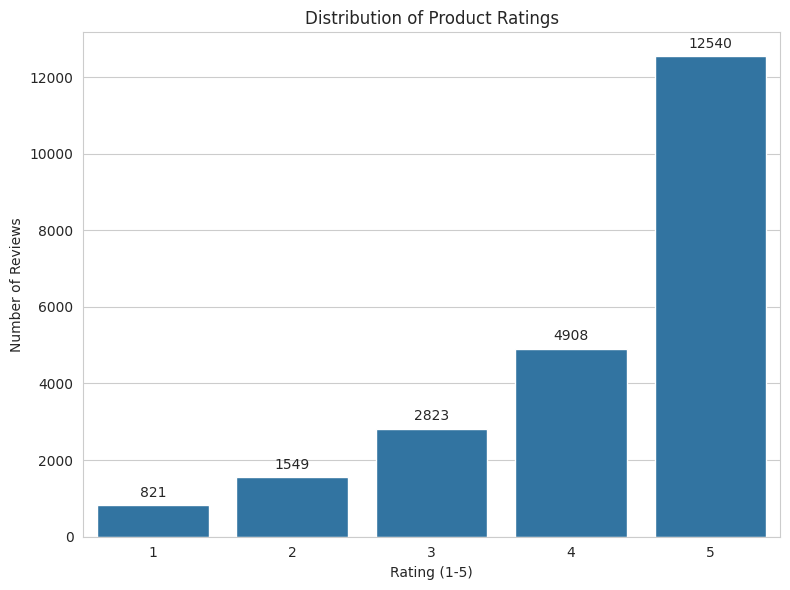

In [72]:
# Distribution plot of product ratings
rating_order = [1, 2, 3, 4, 5]
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x="Rating", order=rating_order)
ax.set_title("Distribution of Product Ratings")
ax.set_xlabel("Rating (1-5)")
ax.set_ylabel("Number of Reviews")
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f"{int(height)}",
                (patch.get_x() + patch.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10, xytext=(0, 4),
                textcoords="offset points")
plt.tight_layout()
plt.show()

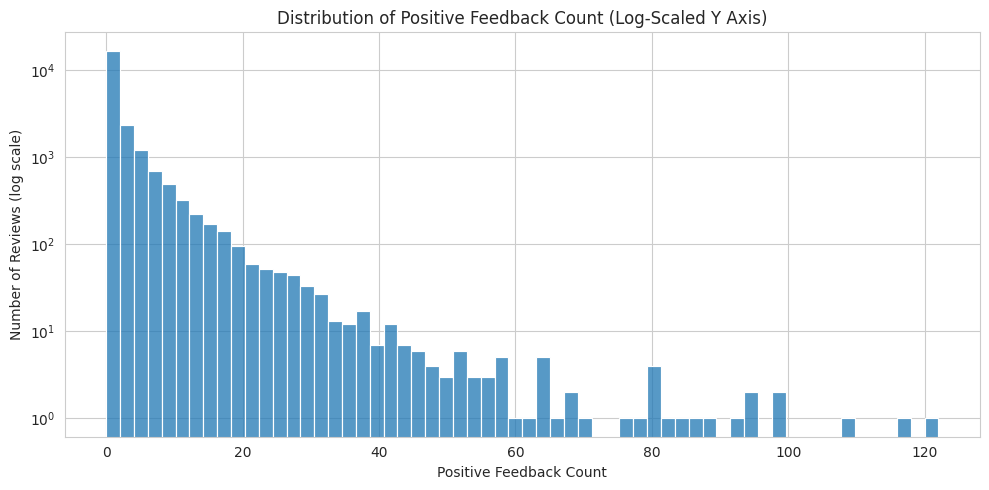

In [69]:
# Distribution plot of positive feedback count
plt.figure(figsize=(10, 5))
ax = sns.histplot(data=df, x="Positive.Feedback.Count", bins=60, edgecolor="white")
ax.set_yscale("log")
ax.set_title("Distribution of Positive Feedback Count (Log-Scaled Y Axis)")
ax.set_xlabel("Positive Feedback Count")
ax.set_ylabel("Number of Reviews (log scale)")
plt.tight_layout()
plt.show()

**Numerical Summary Interpretation**

* `Age` ranges from 18 to 99, with an average of about 43 years and a median age of 41 years. Most reviewers are concentrated between their mid-30s and early-50s, with a smaller number of older customers extending the upper tail of the distribution, making it moderately right-skewed.
* `Rating` has a mean of about 4.18 and a median of 5. The 25th percentile is 4, which shows that most customers gave high ratings. The rating distribution is therefore negatively skewed in the statistical sense, with most ratings at the high end and a smaller tail of low scores.
* `Positive.Feedback.Count` has a mean of about 2.63 but a median of only 1, with a maximum of 122. This indicates a strongly right-skewed distribution. Most reviews receive little or no positive feedback, while a small number of reviews are found helpful by many other customers.

In [12]:
# Unique values in key categorical columns
categorical_cols = ["Division.Name", "Department.Name", "Class.Name"]

unique_counts = (
    df[categorical_cols]
    .nunique(dropna=True)
    .reset_index()
    .rename(columns={"index": "Categorical Column", 0: "Unique Values"})
)
display(unique_counts)

,Categorical Column,Unique Values
0,Division.Name,3
1,Department.Name,6
2,Class.Name,20


In [13]:
# Show the actual category values and review counts for each column
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique(dropna=True)} unique values")
    category_counts = df[col].value_counts(dropna=False).rename_axis(col).reset_index(name="Review Count")
    display(category_counts)


Division.Name: 3 unique values


,Division.Name,Review Count
0,General,13365
1,General Petite,7837
2,Initmates,1426
3,NaN,13



Department.Name: 6 unique values


,Department.Name,Review Count
0,Tops,10048
1,Dresses,6145
2,Bottoms,3662
3,Intimate,1653
4,Jackets,1002
5,Trend,118
6,NaN,13



Class.Name: 20 unique values


,Class.Name,Review Count
0,Dresses,6145
1,Knits,4626
2,Blouses,2983
3,Sweaters,1380
4,Pants,1350
5,Jeans,1104
6,Fine gauge,1059
7,Skirts,903
8,Jackets,683
9,Lounge,669


**Categorical Column Interpretation**

The cleaned dataset contains 3 unique divisions, 6 unique departments, and 20 unique product classes. This gives enough category variety to compare broad business areas such as Tops, Dresses, Bottoms, Intimate, Jackets, and Trend, while the `Class.Name` field provides a more granular product view for detailed merchandising analysis.

In [14]:
# Overall distribution of product ratings
rating_distribution = df["Rating"].value_counts().sort_index().reset_index()
rating_distribution.columns = ["Rating", "Review Count"]
rating_distribution["Percentage"] = (rating_distribution["Review Count"] / len(df) * 100).round(2)
display(rating_distribution)

,Rating,Review Count,Percentage
0,1,821,3.63
1,2,1549,6.84
2,3,2823,12.47
3,4,4908,21.68
4,5,12540,55.39


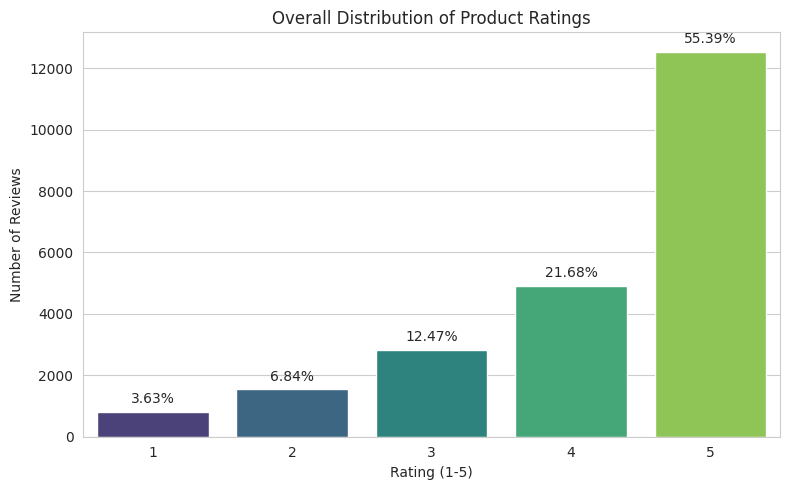

In [73]:
# Plot overall distribution of ratings
plt.figure(figsize=(8, 5))
palette = sns.color_palette("viridis", n_colors=len(rating_distribution))
ax = sns.barplot(data=rating_distribution, x="Rating", y="Review Count", hue="Rating", palette=palette, dodge=False)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title("Overall Distribution of Product Ratings")
ax.set_xlabel("Rating (1-5)")
ax.set_ylabel("Number of Reviews")
for patch, pct in zip(ax.patches, rating_distribution["Percentage"]):
    height = patch.get_height()
    ax.annotate(f"{pct:.2f}%",
                (patch.get_x() + patch.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10, xytext=(0, 4),
                textcoords="offset points")
plt.tight_layout()
plt.show()

In [16]:
# Share of positive and negative ratings
positive_share = rating_distribution.loc[rating_distribution["Rating"].isin([4, 5]), "Review Count"].sum() / len(df) * 100
negative_share = rating_distribution.loc[rating_distribution["Rating"].isin([1, 2]), "Review Count"].sum() / len(df) * 100
print(f"Positive reviews (4-5 stars): {positive_share:.2f}%")
print(f"Negative reviews (1-2 stars): {negative_share:.2f}%")

Positive reviews (4-5 stars): 77.06%
Negative reviews (1-2 stars): 10.47%


**Rating Distribution Interpretation**

The dataset is strongly skewed toward positive reviews. About 55% of reviews are 5-star ratings and about 77% are either 4 or 5 stars. Only about 10% of reviews are 1 or 2 stars. This suggests customers are generally satisfied, but the lower-rated reviews remain especially important because they reveal specific pain points around fit, quality, color accuracy, or expectations.

In [17]:
# Average rating by Department Name
dept_rating = (
    df.groupby("Department.Name")
    .agg(Review_Count=("Rating", "count"), Average_Rating=("Rating", "mean"))
    .sort_values("Average_Rating", ascending=False)
    .reset_index()
)
dept_rating["Average_Rating"] = dept_rating["Average_Rating"].round(3)
display(dept_rating)

highest_dept = dept_rating.iloc[0]
lowest_dept = dept_rating.iloc[-1]
print(f"Highest average rating: {highest_dept['Department.Name']} ({highest_dept['Average_Rating']:.2f})")
print(f"Lowest average rating: {lowest_dept['Department.Name']} ({lowest_dept['Average_Rating']:.2f})")

,Department.Name,Review_Count,Average_Rating
0,Bottoms,3662,4.279
1,Intimate,1653,4.271
2,Jackets,1002,4.254
3,Tops,10048,4.158
4,Dresses,6145,4.139
5,Trend,118,3.839


Highest average rating: Bottoms (4.279)
Lowest average rating: Trend (3.839)


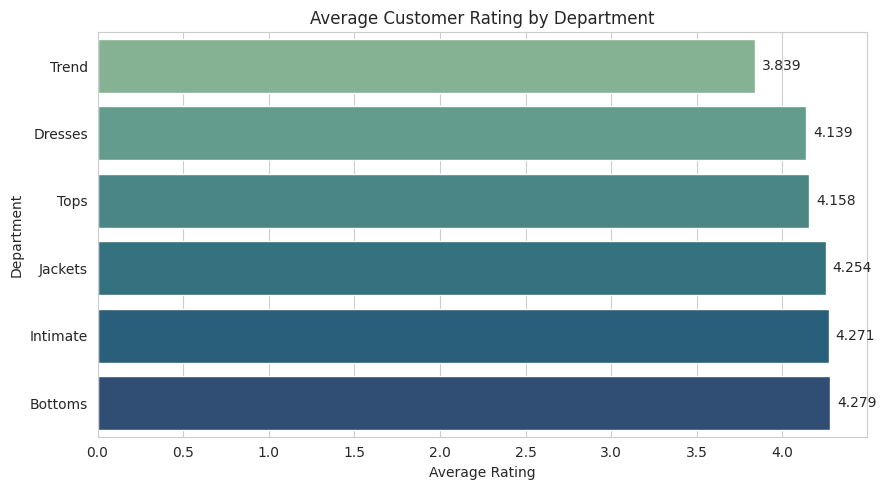

In [74]:
# Plot average rating by department
dept_plot = dept_rating.sort_values("Average_Rating")
plt.figure(figsize=(9, 5))
palette = sns.color_palette("crest", n_colors=len(dept_plot))
ax = sns.barplot(data=dept_plot, x="Average_Rating", y="Department.Name", hue="Department.Name", palette=palette, dodge=False)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title("Average Customer Rating by Department")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Department")
for patch, value in zip(ax.patches, dept_plot["Average_Rating"]):
    width = patch.get_width()
    ax.annotate(f"{value:.2f}",
                (width, patch.get_y() + patch.get_height() / 2),
                ha="left", va="center", fontsize=10, xytext=(5, 0),
                textcoords="offset points")
plt.tight_layout()
plt.show()

**Department Rating Interpretation**

`Bottoms` receives the highest average rating at about 4.279, followed closely by `Intimate` and `Jackets`. `Trend` receives the lowest average rating at about 3.839, although it also has far fewer reviews than the large departments. This may indicate that Bottoms are meeting customer expectations on fit and usability more consistently, while Trend items may involve higher style risk, expectation mismatch, or more variable quality. Because Trend has a small sample size, it should be monitored but interpreted with caution.

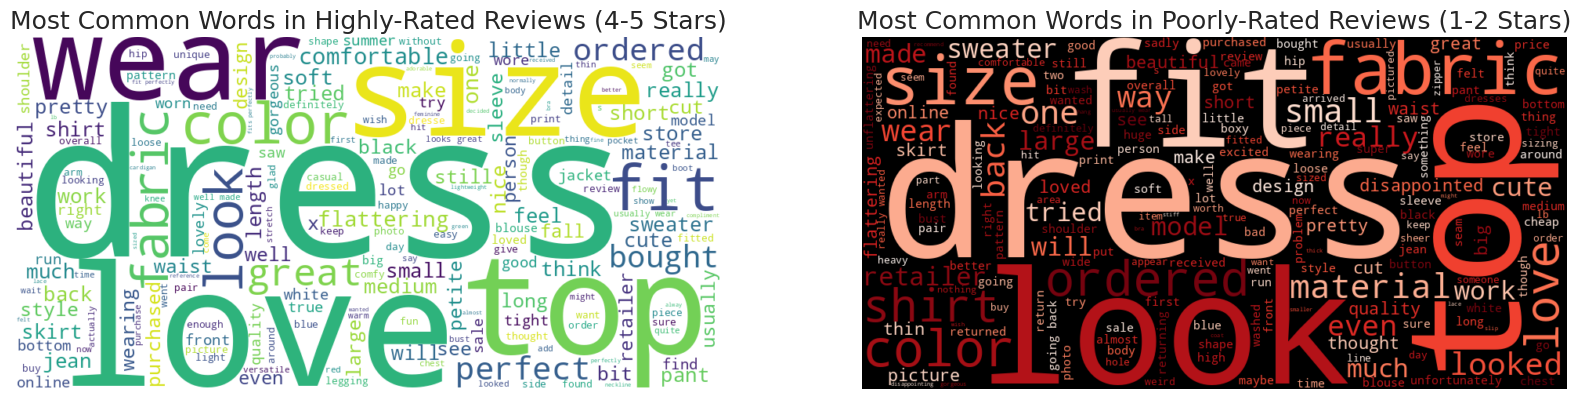

In [19]:
# Word clouds for highly-rated versus poorly-rated reviews
positive_reviews = " ".join(df[df["Rating"].isin([4, 5])]["Review.Text"].astype(str))
negative_reviews = " ".join(df[df["Rating"].isin([1, 2])]["Review.Text"].astype(str))

wordcloud_positive = WordCloud(width=900, height=450, background_color="white").generate(positive_reviews)
wordcloud_negative = WordCloud(width=900, height=450, background_color="black", colormap="Reds").generate(negative_reviews)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
ax1.imshow(wordcloud_positive, interpolation="bilinear")
ax1.set_title("Most Common Words in Highly-Rated Reviews (4-5 Stars)", fontsize=18)
ax1.axis("off")

ax2.imshow(wordcloud_negative, interpolation="bilinear")
ax2.set_title("Most Common Words in Poorly-Rated Reviews (1-2 Stars)", fontsize=18)
ax2.axis("off")
plt.show()

In [20]:
# Frequency table of most common words in positive and negative reviews
def top_terms(text_series, n=20):
    vectorizer = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=10)
    term_matrix = vectorizer.fit_transform(text_series.astype(str))
    frequencies = np.asarray(term_matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    return (
        pd.DataFrame({"Term": terms, "Frequency": frequencies})
        .sort_values("Frequency", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

print("Top terms in highly-rated reviews (4-5 stars):")
display(top_terms(df[df["Rating"].isin([4, 5])]["Review.Text"]))

print("Top terms in poorly-rated reviews (1-2 stars):")
display(top_terms(df[df["Rating"].isin([1, 2])]["Review.Text"]))

Top terms in highly-rated reviews (4-5 stars):


,Term,Frequency
0,dress,8036
1,love,7742
2,size,7079
3,fit,5630
4,wear,5422
5,great,5417
6,like,4928
7,just,4011
8,color,3634
9,small,3531


Top terms in poorly-rated reviews (1-2 stars):


,Term,Frequency
0,dress,1123
1,like,1076
2,fabric,712
3,fit,687
4,size,677
5,just,667
6,small,518
7,look,516
8,ordered,512
9,really,474


**Word Cloud Interpretation and Initial Hypotheses**

Highly-rated reviews tend to contain words and phrases related to positive fit, emotional satisfaction, and styling appeal, such as love, great, perfect, fit, comfortable, flattering, size, dress, and wear. This suggests that customer satisfaction is driven by items that fit well, feel comfortable, look attractive, and match the customer's style expectations.

Poorly-rated reviews more often emphasize disappointment and mismatch, with recurring terms around fit, size, small, fabric, looked, quality, return, and wanted. This suggests dissatisfaction is often driven by sizing problems, poor fit, fabric or construction quality concerns, and gaps between product expectations and the actual item received.

An initial business hypothesis is that ChicStyle can improve customer satisfaction by strengthening size guidance, product images/descriptions, and fabric-quality controls. Fit and product expectation management appear to be the most important levers for reducing negative reviews.

## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results.

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

In Google Colab, store the API key in Colab secrets as `OPENAI_API_KEY`, retrieve it with `userdata.get("OPENAI_API_KEY")`, and pass it to the OpenAI client along with the Great Learning base URL. The model name should be stored once in `model_name` so every later cell uses the same model consistently.

In [21]:
# Fetch API key
api_key = userdata.get('OPENAI_API_KEY')

# Initialize OpenAI client
client = openai.OpenAI(
    api_key=api_key,
    base_url="https://aibe.mygreatlearning.com/openai/v1"
)

model_name = "gpt-4o-mini"

#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

In [22]:
# Create a sample of 50 reviews to work with
df_sample_copy = df.sample(n=50, random_state=42).reset_index(drop=True)

#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2). Each prompt now returns seven structured fields so the solution can support both insight generation and operational routing.

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

A consistent evaluation framework is important because prompt outputs can vary in style, detail, and usefulness. Without a common rubric, comparisons across Zero-Shot, Few-Shot, and Chain-of-Thought prompts become subjective. An LLM-as-Judge can apply the same scoring criteria to every generated output and return a numeric score between 0 and 1 for relevance, feedback-type accuracy, urgency assignment, sentiment correctness, structure, personalization, and business usefulness. The judge should be kept deterministic with temperature=0 and should be instructed to return only a score.

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1. How would you design a basic Zero-Shot prompt that asks the model for `Feedback_Type`, `Category`, `Sentiment`, `Urgency_Level`, `Summary`, `Personalized Message`, and `Retail Insight`?
2. How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy, and routing rules) to create a V2 prompt?
3. How will you loop through the data sample to generate and store the structured output for both prompt versions?
4. How will you apply the LLM-as-Judge to generate an evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?

**How the process works:**

1. First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
2. Then, you run your **Zero-Shot Prompt Version 1** on a sample of 50 reviews to generate predictions.
3. You use the judge function to **score each prediction** and compute the **average score for Version 1**.
4. Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.


**Answers:**

1. A basic Zero-Shot prompt should directly ask the model to analyze the review and return exactly seven labeled fields: `Feedback_Type`, `Category`, `Sentiment`, `Urgency_Level`, `Summary`, `Personalized Message`, and `Retail Insight`. The output format needs to be strict so the parser can extract the fields.
2. The stronger V2 Zero-Shot prompt adds business context: ChicStyle is handling high-volume holiday feedback, accuracy matters for customer trust, and urgent product or service issues must be routed clearly. This helps the model produce more operationally useful summaries, urgency labels, and insights.
3. The notebook loops through the 50-review sample with `tqdm`, calls `generate_output(review, prompt)` for each review, converts the list of dictionaries into a DataFrame, prefixes the columns by prompt version, and concatenates the results back to `df_sample`.
4. The LLM-as-Judge receives each review plus the generated structured output, applies the same seven-field rubric, returns a score from 0 to 1, and the average score is calculated for each prompt version.


In [23]:
# Core LLM helper functions
STRUCTURED_FIELDS = [
    "Feedback_Type",
    "Category",
    "Sentiment",
    "Urgency_Level",
    "Summary",
    "Personalized_Message",
    "Retail_Insight"
]

VALID_FEEDBACK_TYPES = {"Product", "Service", "Mixed", "Other"}
VALID_URGENCY_LEVELS = {"High", "Medium", "Low"}


def call_chat_model(messages, model=model_name, temperature=0.0, max_tokens=500, max_retries=5, base_wait=2):
    """Wrapper with basic retry logic for transient API/rate-limit failures."""
    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            return client.chat.completions.create(
                model=model,
                temperature=temperature,
                max_tokens=max_tokens,
                messages=messages
            )
        except Exception as e:
            last_error = e
            if attempt == max_retries:
                raise
            wait_time = min(base_wait * attempt, 15)
            print(f"Attempt {attempt}/{max_retries} failed with {type(e).__name__}. Retrying in {wait_time} seconds...")
            time.sleep(wait_time)
    raise last_error


def infer_feedback_type(review_text="", category="", summary="", retail_insight=""):
    """Infer Product/Service/Mixed/Other when the LLM omits or misformats Feedback_Type."""
    combined = " ".join([str(review_text), str(category), str(summary), str(retail_insight)]).lower()
    product_terms = [
        "fit", "size", "sizing", "fabric", "material", "quality", "color", "image",
        "photo", "dress", "top", "pants", "skirt", "sweater", "zipper", "seam",
        "style", "design", "comfort", "petite", "runs small", "runs large"
    ]
    service_terms = [
        "delivery", "shipping", "ship", "late", "delay", "return", "exchange",
        "refund", "customer service", "support", "order", "package", "store pickup"
    ]
    has_product = any(term in combined for term in product_terms)
    has_service = any(term in combined for term in service_terms)
    if has_product and has_service:
        return "Mixed"
    if has_product:
        return "Product"
    if has_service:
        return "Service"
    return "Other"


def infer_urgency_level(review_text="", sentiment="", category="", summary=""):
    """Infer High/Medium/Low urgency when the LLM omits or misformats Urgency_Level."""
    combined = " ".join([str(review_text), str(sentiment), str(category), str(summary)]).lower()
    sentiment_clean = str(sentiment).strip().lower()
    high_terms = [
        "defective", "damaged", "ripped", "hole", "broken", "cannot wear", "can't wear",
        "could not zip", "would not zip", "terrible", "awful", "unwearable", "never arrived",
        "wrong item", "completely", "returning", "returned"
    ]
    medium_terms = [
        "too small", "too large", "runs small", "runs large", "tight", "loose", "itchy",
        "thin", "transparent", "see through", "color", "quality", "delivery", "late",
        "delay", "exchange", "refund", "disappointed"
    ]
    if sentiment_clean == "negative" and any(term in combined for term in high_terms):
        return "High"
    if sentiment_clean == "negative" or any(term in combined for term in medium_terms):
        return "Medium"
    return "Low"


def normalize_feedback_type(value, review_text="", category="", summary="", retail_insight=""):
    cleaned = str(value).strip().title()
    if cleaned in VALID_FEEDBACK_TYPES:
        return cleaned
    return infer_feedback_type(review_text, category, summary, retail_insight)


def normalize_urgency_level(value, review_text="", sentiment="", category="", summary=""):
    cleaned = str(value).strip().title()
    if cleaned in VALID_URGENCY_LEVELS:
        return cleaned
    return infer_urgency_level(review_text, sentiment, category, summary)


def enrich_structured_output(out, review_text):
    out["Feedback_Type"] = normalize_feedback_type(
        out.get("Feedback_Type", ""),
        review_text=review_text,
        category=out.get("Category", ""),
        summary=out.get("Summary", ""),
        retail_insight=out.get("Retail_Insight", "")
    )
    out["Urgency_Level"] = normalize_urgency_level(
        out.get("Urgency_Level", ""),
        review_text=review_text,
        sentiment=out.get("Sentiment", ""),
        category=out.get("Category", ""),
        summary=out.get("Summary", "")
    )
    return out


def get_structured_output(review_text: str, prompt: str) -> dict:
    empty_output = {field: "" for field in STRUCTURED_FIELDS}

    try:
        resp = call_chat_model(
            model=model_name,
            temperature=0.0,
            max_tokens=500,
            messages=[
                {"role": "system", "content": "You are a precise retail feedback analyst. Return only the requested labeled fields."},
                {"role": "user", "content": f"{prompt}\n\nReview: {review_text}"}
            ]
        )
    except Exception as e:
        out = empty_output.copy()
        out["Summary"] = f"ERROR_CALL: {type(e).__name__}: {e}"
        out["Sentiment"] = "Error"
        return out

    text = resp.choices[0].message.content or ""
    out = empty_output.copy()

    try:
        parsed = json.loads(text)
        if isinstance(parsed, dict):
            key_map = {
                "feedback type": "Feedback_Type",
                "feedback_type": "Feedback_Type",
                "type": "Feedback_Type",
                "category": "Category",
                "sentiment": "Sentiment",
                "urgency level": "Urgency_Level",
                "urgency_level": "Urgency_Level",
                "urgency": "Urgency_Level",
                "summary": "Summary",
                "personalized message": "Personalized_Message",
                "personalized_message": "Personalized_Message",
                "retail insight": "Retail_Insight",
                "retail_insight": "Retail_Insight"
            }
            for key, value in parsed.items():
                normalized_key = str(key).strip().lower().replace("-", " ")
                if normalized_key in key_map:
                    out[key_map[normalized_key]] = str(value).strip()
            if any(out.values()):
                return enrich_structured_output(out, review_text)
    except Exception:
        pass

    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]
    for line in lines:
        line = re.sub(r"^[\-\*\d\.\)\s]+", "", line)
        if ":" not in line:
            continue
        key_raw, val = line.split(":", 1)
        key = key_raw.strip().lower().replace("_", " ")
        val = val.strip()
        if key.startswith("feedback") or key == "type":
            out["Feedback_Type"] = val
        elif key.startswith("category"):
            out["Category"] = val
        elif key.startswith("sentiment"):
            out["Sentiment"] = val.title()
        elif key.startswith("urgency"):
            out["Urgency_Level"] = val
        elif key.startswith("summary"):
            out["Summary"] = val
        elif "personal" in key:
            out["Personalized_Message"] = val
        elif "insight" in key:
            out["Retail_Insight"] = val
    return enrich_structured_output(out, review_text)


In [24]:
# Prompting strategies and evaluation framework
def generate_output(review_text, prompt):
    return get_structured_output(review_text, prompt)


def format_for_judge(row, prefix):
    return f"""
Review:
{row.get('Review.Text', '')}

Generated Output:
Feedback Type: {row.get(prefix + '_Feedback_Type', '')}
Category: {row.get(prefix + '_Category', '')}
Sentiment: {row.get(prefix + '_Sentiment', '')}
Urgency Level: {row.get(prefix + '_Urgency_Level', '')}
Summary: {row.get(prefix + '_Summary', '')}
Personalized Message: {row.get(prefix + '_Personalized_Message', '')}
Retail Insight: {row.get(prefix + '_Retail_Insight', '')}
""".strip()


judge_prompt = """
You are an impartial evaluator for a retail feedback intelligence system.
Score the generated output against the original review.

Rubric:
- 0.15 correct feedback type: Product, Service, Mixed, or Other
- 0.15 useful and specific business category
- 0.15 correct sentiment and tone interpretation
- 0.15 appropriate urgency level: High, Medium, or Low
- 0.15 accurate and concise summary
- 0.10 empathetic, specific personalized message
- 0.15 actionable retail insight

Return only one decimal number from 0 to 1. Do not include words, bullets, or explanations.

{output}
"""


def judge_output(output_text):
    try:
        resp = call_chat_model(
            model=model_name,
            temperature=0,
            max_tokens=10,
            messages=[
                {"role": "system", "content": "You are a strict evaluator that returns only a numeric score."},
                {"role": "user", "content": judge_prompt.format(output=output_text)}
            ]
        )
        score_str = resp.choices[0].message.content.strip()
        match = re.search(r"0(?:\.\d+)?|1(?:\.0+)?", score_str)
        if not match:
            return None
        return max(0.0, min(1.0, float(match.group(0))))
    except Exception:
        return None


def parse_success_rate(df_frame, prefix):
    required_cols = [f"{prefix}_{field}" for field in STRUCTURED_FIELDS]
    missing_cols = [col for col in required_cols if col not in df_frame.columns]
    if missing_cols:
        return 0.0
    return df_frame[required_cols].fillna("").apply(
        lambda row: all(str(v).strip() != "" for v in row), axis=1
    ).mean()


In [25]:
print("Zero-Shot Version 1 predictions:")
df_sample = df_sample_copy.copy()

# Define the first version of your Zero-Shot prompt.
zero_shot_prompt_v1 = """Analyze the customer review and return exactly seven lines in this format:
Feedback Type: <Product, Service, Mixed, or Other>
Category: <main issue or praise area>
Sentiment: <Positive, Negative, or Neutral>
Urgency Level: <High, Medium, or Low>
Summary: <one concise sentence>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
zs_list = [generate_output(review, zero_shot_prompt_v1) for review in tqdm(df_sample["Review.Text"], desc="Zero-Shot Predictions")]
zs_df = pd.DataFrame(zs_list)
df_sample = pd.concat([df_sample, zs_df.add_prefix("ZS_V1_")], axis=1)
df_sample.head()


Zero-Shot Version 1 predictions:


Zero-Shot Predictions: 100%|██████████| 50/50 [02:04<00:00,  2.49s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,ZS_V1_Category,ZS_V1_Sentiment,ZS_V1_Summary,ZS_V1_Personalized_Message,ZS_V1_Retail_Insight
0,948,24,Stunning!,"This sweater is so beautiful on. it is thick material, but does not make you look boxy. it fits so nicely and is flattering. the design is just gorgeous. if you are considering this sweater-- get ...",5,1,4,General,Tops,Sweaters,Fit and Design,Positive,The customer praises the sweater for its flattering fit and beautiful design.,We're thrilled to hear that you love the fit and style of your new sweater!,Highlight the true-to-size fit and flattering design in marketing materials to attract more customers.
1,875,63,NaN,"This piece is almost what i want... i tried on the white version in an xs and it felt a little too large for me, even though it's meant to be a looser fit. the buttercup yellow behind the lace is ...",4,1,38,General,Tops,Knits,Fit and Texture,Neutral,The customer appreciates the design but finds the fit and texture unsatisfactory.,We understand how important the right fit and texture are for your comfort and style.,Consider offering a size guide and fabric details to help customers make more informed choices.
2,829,42,Nice blouse,Really like this blouse but am returning for a larger size. much too tight in the upper arms and somewhat tight in the chest - overall i like it.,4,1,0,General,Tops,Blouses,Sizing Issues,Neutral,The customer enjoys the blouse but finds it too tight in certain areas and is returning it for a larger size.,We appreciate your feedback and understand how important the right fit is for your comfort.,Consider offering a wider range of sizes or adjusting the fit in the upper arms and chest to enhance customer satisfaction.
3,1068,39,Perfect summer pants,"These are the perfect light weight relaxing summer pants!\r\nthe fabric is soft and light, and has some stretch, so i think they can be worn more fitted way, too. \r\ni don't want to show off my b...",5,1,0,General Petite,Bottoms,Pants,Fit and Comfort,Positive,"The customer appreciates the lightweight, soft fabric and flattering fit of the summer pants.",We're thrilled to hear that our pants provide the perfect blend of comfort and style for you!,Highlight the versatility of fit options in marketing to attract customers looking for both comfort and style.
4,1030,44,Terrible cut,These look nothing like the picture! they are super high-waisted & longer than they look in this picture. i felt as if i was wearing a pair of jeans from the 90's that just fit terribly. i thought...,2,1,4,General,Bottoms,Jeans,Product Misrepresentation,Negative,The customer is disappointed with the product's fit and color compared to the online image.,"We understand how frustrating it can be when a product doesn't meet your expectations, and we appreciate your feedback.",Improve product images and descriptions to better reflect the actual fit and color to reduce return rates.


In [26]:
print("Judgement of Zero-Shot V1 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
zs_scores = [
    judge_output(format_for_judge(row, "ZS_V1"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge ZS_V1")
]
df_sample["ZS_V1_Score"] = zs_scores
print(f"Avg ZS_V1_Score: {df_sample['ZS_V1_Score'].mean():.2f}")

Judgement of Zero-Shot V1 outputs:


Judge ZS_V1: 100%|██████████| 50/50 [00:36<00:00,  1.38it/s]

Avg ZS_V1_Score: 0.914


In [27]:
print("Zero-Shot V2 predictions (context-enhanced):")

# Define the second version of your Zero-Shot prompt.
zero_shot_prompt_v2 = """You are analyzing real-time holiday-season reviews for ChicStyle, a fashion retail platform. Accuracy matters because delayed or incorrect review handling can damage customer trust during peak sales periods.

Classify the review using retail business context. Prioritize issues related to fit, sizing, product quality, comfort, color/image mismatch, delivery/service, and value.

Feedback Type rules:
- Product: the review is mainly about the item, fit, size, fabric, color, quality, comfort, or style.
- Service: the review is mainly about delivery, shipping, returns, support, store pickup, or order experience.
- Mixed: the review includes both product and service issues.
- Other: the review does not clearly fit product or service.

Urgency Level rules:
- High: serious negative complaint, defect, unusable item, strongly dissatisfied customer, or issue needing fast follow-up.
- Medium: fixable fit, quality, color, delivery, or expectation issue that should be monitored or addressed.
- Low: positive review, minor suggestion, or no immediate operational risk.

If a review contains mixed feedback, choose Neutral unless the overall tone clearly leans positive or negative.

Return exactly seven lines and no extra commentary:
Feedback Type: <Product, Service, Mixed, or Other>
Category: <specific business category>
Sentiment: <Positive, Negative, or Neutral>
Urgency Level: <High, Medium, or Low>
Summary: <one concise sentence grounded in the review>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight for ChicStyle>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
zsv2_list = [generate_output(review, zero_shot_prompt_v2) for review in tqdm(df_sample["Review.Text"], desc="Zero-Shot V2 Predictions")]
zsv2_df = pd.DataFrame(zsv2_list)
df_sample = pd.concat([df_sample, zsv2_df.add_prefix("ZS_V2_")], axis=1)
df_sample.head()


Zero-Shot V2 predictions (context-enhanced):


Zero-Shot V2 Predictions: 100%|██████████| 50/50 [02:07<00:00,  2.55s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,...,ZS_V1_Sentiment,ZS_V1_Summary,ZS_V1_Personalized_Message,ZS_V1_Retail_Insight,ZS_V1_Score,ZS_V2_Category,ZS_V2_Sentiment,ZS_V2_Summary,ZS_V2_Personalized_Message,ZS_V2_Retail_Insight
0,948,24,Stunning!,"This sweater is so beautiful on. it is thick material, but does not make you look boxy. it fits so nicely and is flattering. the design is just gorgeous. if you are considering this sweater-- get ...",5,1,4,General,Tops,Sweaters,...,Positive,The customer praises the sweater for its flattering fit and beautiful design.,We're thrilled to hear that you love the fit and style of your new sweater!,Highlight the true-to-size fit and flattering design in marketing materials to attract more customers.,1.0,Fit,Positive,"The sweater fits true to size and is flattering, making it a beautiful choice.",We're thrilled to hear that the sweater fits you perfectly and enhances your look!,ChicStyle should highlight fit information and customer recommendations for sizing in product descriptions.
1,875,63,NaN,"This piece is almost what i want... i tried on the white version in an xs and it felt a little too large for me, even though it's meant to be a looser fit. the buttercup yellow behind the lace is ...",4,1,38,General,Tops,Knits,...,Neutral,The customer appreciates the design but finds the fit and texture unsatisfactory.,We understand how important the right fit and texture are for your comfort and style.,Consider offering a size guide and fabric details to help customers make more informed choices.,0.8,Fit/Sizing,Neutral,The reviewer finds the fit slightly large but appreciates the color and design details.,"We understand that finding the perfect fit can be challenging, and we appreciate your feedback on the sizing.",ChicStyle should consider providing more detailed sizing information and fabric descriptions to help customers make informed choices.
2,829,42,Nice blouse,Really like this blouse but am returning for a larger size. much too tight in the upper arms and somewhat tight in the chest - overall i like it.,4,1,0,General,Tops,Blouses,...,Neutral,The customer enjoys the blouse but finds it too tight in certain areas and is returning it for a larger size.,We appreciate your feedback and understand how important the right fit is for your comfort.,Consider offering a wider range of sizes or adjusting the fit in the upper arms and chest to enhance customer satisfaction.,0.8,Fit/Sizing,Neutral,The blouse is liked but is being returned due to sizing issues in the upper arms and chest.,"We understand that finding the perfect fit can be challenging, and we appreciate your feedback.",ChicStyle should consider providing more detailed sizing information and fit guides to assist customers in making better choices.
3,1068,39,Perfect summer pants,"These are the perfect light weight relaxing summer pants!\r\nthe fabric is soft and light, and has some stretch, so i think they can be worn more fitted way, too. \r\ni don't want to show off my b...",5,1,0,General Petite,Bottoms,Pants,...,Positive,"The customer appreciates the lightweight, soft fabric and flattering fit of the summer pants.",We're thrilled to hear that our pants provide the perfect blend of comfort and style for you!,Highlight the versatility of fit options in marketing to attract customers looking for both comfort and style.,0.9,Fit,Positive,The reviewer appreciates the lightweight fabric and perfect fit of the summer pants.,We're thrilled to hear that you found the perfect fit and style for your summer wardrobe!,Monitor customer feedback on sizing options to ensure a consistent fit across different body types.
4,1030,44,Terrible cut,These look nothing like the picture! they are super high-waisted & longer than they look in this picture. i felt as if i was wearing a pair of jeans from the 90's that just fit terribly. i thought...,2,1,4,General,Bottoms,Jeans,...,Nega

In [28]:
print("Judging Zero-Shot V2 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
zsv2_scores = [
    judge_output(format_for_judge(row, "ZS_V2"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge ZS_V2")
]
df_sample["ZS_V2_Score"] = zsv2_scores
print(f"Avg ZS_V2_Score: {df_sample['ZS_V2_Score'].mean():.2f}")

Judging Zero-Shot V2 outputs:


Judge ZS_V2: 100%|██████████| 50/50 [00:38<00:00,  1.31it/s]

Avg ZS_V2_Score: 0.862


#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?


    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?


    
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?



**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Few-Shot Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

**Answers:**

1. A Few-Shot prompt should include the task instructions plus a small set of high-quality examples showing the desired input-output pattern. The best examples are representative and contrasting: at least one clearly positive review, one clearly negative review, and one mixed/neutral review. This teaches the model both the desired labels and exact output structure, including `Feedback_Type` and `Urgency_Level`.
2. The V2 prompt can add explicit rules for each field: choose one dominant category, use only Product/Service/Mixed/Other for feedback type, use only Positive/Negative/Neutral for sentiment, use only High/Medium/Low for urgency, keep the summary factual, make the personalized message empathetic but not overpromising, and make actionable retail insights for merchandising, product, or customer experience teams.
3. Few-Shot prompting performed well, but not better than the best Zero-Shot version. The final solution therefore uses Few-Shot outputs for comparison while selecting the simpler Zero-Shot V1 design for production.


In [29]:
print("Few-Shot V1 predictions:")

# Define V1 of the Few-Shot prompt.
few_shot_prompt_v1 = """Analyze the customer review and return the same seven fields shown in the examples.

Example 1
Review: Love this dress. It fits perfectly and the fabric feels soft.
Feedback Type: Product
Category: Fit and Comfort
Sentiment: Positive
Urgency Level: Low
Summary: The customer loves the dress because it fits well and feels comfortable.
Personalized Message: Thank you for sharing your experience; we are glad the fit and fabric worked so well for you.
Retail Insight: Fit and fabric comfort are strong selling points for this item.

Example 2
Review: The color looked nothing like the photo and the material felt cheap.
Feedback Type: Product
Category: Color/Image Accuracy and Quality
Sentiment: Negative
Urgency Level: Medium
Summary: The customer is disappointed because the color and material did not match expectations.
Personalized Message: We are sorry the item did not match what you expected and appreciate you sharing this feedback.
Retail Insight: Review product photos and material descriptions to reduce expectation mismatch.

Example 3
Review: The top is cute, but it arrived late and the sleeves stretched out after one wash.
Feedback Type: Mixed
Category: Delivery/Service and Product Quality
Sentiment: Neutral
Urgency Level: Medium
Summary: The customer liked the style but reported late delivery and sleeve durability issues.
Personalized Message: Thank you for the honest feedback; we are sorry the delivery and sleeve quality did not fully meet expectations.
Retail Insight: Monitor delivery timeliness and sleeve durability for this product line.

Now analyze the new review. Return exactly seven lines:
Feedback Type: <Product, Service, Mixed, or Other>
Category: <main issue or praise area>
Sentiment: <Positive, Negative, or Neutral>
Urgency Level: <High, Medium, or Low>
Summary: <one concise sentence>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
fs_v1_list = [generate_output(review, few_shot_prompt_v1) for review in tqdm(df_sample["Review.Text"], desc="Few-Shot V1 Predictions")]
fs_v1_df = pd.DataFrame(fs_v1_list)
df_sample = pd.concat([df_sample, fs_v1_df.add_prefix("FS_V1_")], axis=1)
df_sample.head()


Few-Shot V1 predictions:


Few-Shot V1 Predictions: 100%|██████████| 50/50 [01:34<00:00,  1.88s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,...,ZS_V2_Sentiment,ZS_V2_Summary,ZS_V2_Personalized_Message,ZS_V2_Retail_Insight,ZS_V2_Score,FS_V1_Category,FS_V1_Sentiment,FS_V1_Summary,FS_V1_Personalized_Message,FS_V1_Retail_Insight
0,948,24,Stunning!,"This sweater is so beautiful on. it is thick material, but does not make you look boxy. it fits so nicely and is flattering. the design is just gorgeous. if you are considering this sweater-- get ...",5,1,4,General,Tops,Sweaters,...,Positive,"The sweater fits true to size and is flattering, making it a beautiful choice.",We're thrilled to hear that the sweater fits you perfectly and enhances your look!,ChicStyle should highlight fit information and customer recommendations for sizing in product descriptions.,0.9,Fit and Design,Positive,"The customer finds the sweater beautiful, flattering, and true to size.",Thank you for your wonderful feedback; we're thrilled to hear the fit and design exceeded your expectations!,Highlight the flattering fit and true-to-size nature in product descriptions to encourage purchases.
1,875,63,NaN,"This piece is almost what i want... i tried on the white version in an xs and it felt a little too large for me, even though it's meant to be a looser fit. the buttercup yellow behind the lace is ...",4,1,38,General,Tops,Knits,...,Neutral,The reviewer finds the fit slightly large but appreciates the color and design details.,"We understand that finding the perfect fit can be challenging, and we appreciate your feedback on the sizing.",ChicStyle should consider providing more detailed sizing information and fabric descriptions to help customers make informed choices.,0.8,Fit/Sizing and Product Quality,Neutral,The customer appreciates the color and design but finds the fit too large and dislikes the texture of the spandex.,Thank you for your feedback; we’re glad you liked the colors but are sorry to hear about the fit and texture issues.,Consider reviewing the sizing description and fabric texture for better customer satisfaction.
2,829,42,Nice blouse,Really like this blouse but am returning for a larger size. much too tight in the upper arms and somewhat tight in the chest - overall i like it.,4,1,0,General,Tops,Blouses,...,Neutral,The blouse is liked but is being returned due to sizing issues in the upper arms and chest.,"We understand that finding the perfect fit can be challenging, and we appreciate your feedback.",ChicStyle should consider providing more detailed sizing information and fit guides to assist customers in making better choices.,0.8,Fit/Sizing,Neutral,The customer likes the blouse but is returning it due to tightness in the upper arms and chest.,We appreciate your feedback and understand the importance of finding the right fit.,Consider providing more detailed sizing information to help customers choose the correct size.
3,1068,39,Perfect summer pants,"These are the perfect light weight relaxing summer pants!\r\nthe fabric is soft and light, and has some stretch, so i think they can be worn more fitted way, too. \r\ni don't want to show off my b...",5,1,0,General Petite,Bottoms,Pants,...,Positive,The reviewer appreciates the lightweight fabric and perfect fit of the summer pants.,We're thrilled to hear that you found the perfect fit and style for your summer wardrobe!,Monitor customer feedback on sizing options to ensure a consistent fit across different body types.,0.9,Fit and Comfort,Positive,The customer finds the summer pants perfect for a relaxed fit while maintaining a feminine look.,Thank you for your feedback; we're thrilled to hear the pants provide the comfort and style you were looking for!,Highlight the versatility and comfort of the fabric in marketing to attract similar customers.
4,1030,44,Terrible cut,These look nothing like the picture! they are super high-waisted & longer than they look in this picture. i felt as if i was wearing a pair of jeans 

In [30]:
print("Judgement of Few-Shot V1 outputs:")

# Loop through the generated outputs and use the judge_output function to score them.
fs_v1_scores = [
    judge_output(format_for_judge(row, "FS_V1"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge FS_V1")
]
df_sample["FS_V1_Score"] = fs_v1_scores
print(f"Avg FS_V1_Score: {df_sample['FS_V1_Score'].mean():.2f}")

Judgement of Few-Shot V1 outputs:


Judge FS_V1: 100%|██████████| 50/50 [00:28<00:00,  1.75it/s]

Avg FS_V1_Score: 0.904


In [31]:
print("Few-Shot V2 predictions (context-enhanced):")

# Define the second version of your few-Shot prompt.
few_shot_prompt_v2 = """You are ChicStyle's retail feedback analyst. Use the examples and rules below to produce consistent structured outputs.

Rules:
1. Feedback Type must be exactly Product, Service, Mixed, or Other.
2. Category must be specific, such as Fit/Sizing, Product Quality, Style/Design, Comfort, Color/Image Accuracy, Delivery/Service, Price/Value, or General Experience.
3. Sentiment must be exactly Positive, Negative, or Neutral. Use Neutral for mixed reviews with balanced praise and criticism.
4. Urgency Level must be exactly High, Medium, or Low.
5. Summary must be factual and no more than 25 words.
6. Personalized Message must be customer-facing, empathetic, and should not promise refunds or actions not stated in the review.
7. Retail Insight must be useful for merchandising, product, quality, support, or e-commerce teams.

Urgency guide:
- High: severe complaint, unusable/defective item, strong dissatisfaction, or issue requiring immediate human follow-up.
- Medium: fit, quality, color, delivery, or expectation issue that should be monitored and addressed.
- Low: positive feedback, minor suggestion, or no urgent operational risk.

Example 1
Review: I love the pants. They fit true to size and the fabric is comfortable enough for all-day wear.
Feedback Type: Product
Category: Fit/Sizing and Comfort
Sentiment: Positive
Urgency Level: Low
Summary: The customer is pleased with the true-to-size fit and comfortable fabric.
Personalized Message: Thank you for the feedback; we are happy the fit and comfort worked well for you.
Retail Insight: Promote true-to-size fit and comfort in product messaging.

Example 2
Review: The dress is pretty, but it arrived two days late and the zipper broke the first time I wore it.
Feedback Type: Mixed
Category: Delivery/Service and Product Quality
Sentiment: Negative
Urgency Level: High
Summary: The customer liked the appearance but had late delivery and a zipper failure.
Personalized Message: We are sorry the delivery and zipper quality fell short and appreciate you flagging this.
Retail Insight: Escalate zipper durability and late-delivery complaints for quality and support review.

Example 3
Review: The sweater is soft, but the sleeves stretched out quickly after wearing it once.
Feedback Type: Product
Category: Product Quality
Sentiment: Neutral
Urgency Level: Medium
Summary: The customer liked the sweater's softness but noticed poor sleeve recovery after one wear.
Personalized Message: Thank you for sharing this; we are glad the sweater felt soft but sorry the sleeves stretched out.
Retail Insight: Investigate sleeve recovery and fabric durability while preserving softness.

Now analyze the new review. Return exactly seven lines and no extra text:
Feedback Type: <Product, Service, Mixed, or Other>
Category: <main issue or praise area>
Sentiment: <Positive, Negative, or Neutral>
Urgency Level: <High, Medium, or Low>
Summary: <one concise sentence>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
fs_v2_list = [generate_output(review, few_shot_prompt_v2) for review in tqdm(df_sample["Review.Text"], desc="Few-Shot V2 Predictions")]
fs_v2_df = pd.DataFrame(fs_v2_list)
df_sample = pd.concat([df_sample, fs_v2_df.add_prefix("FS_V2_")], axis=1)
df_sample.head()


Few-Shot V2 predictions (context-enhanced):


Few-Shot V2 Predictions: 100%|██████████| 50/50 [01:36<00:00,  1.93s/it]


In [32]:
print("Judgement of Few-Shot V2 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
fs_v2_scores = [
    judge_output(format_for_judge(row, "FS_V2"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge FS_V2")
]
df_sample["FS_V2_Score"] = fs_v2_scores
print(f"Avg FS_V2_Score: {df_sample['FS_V2_Score'].mean():.2f}")

Judgement of Few-Shot V2 outputs:


Judge FS_V2: 100%|██████████| 50/50 [00:33<00:00,  1.49it/s]

Avg FS_V2_Score: 0.878


#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?
    
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **CoT Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

**Answers:**

1. The prompt should instruct the model to reason internally before answering, but it should also explicitly say: "Do not show your reasoning. Return only the final structured answer." This gets the benefit of deliberate analysis without exposing verbose reasoning or breaking the parser.

2. CoT V2 can combine internal reasoning with stronger business context and field-level rules. The model can silently check the review for feedback type, sentiment, main issue, urgency, customer impact, and business action before returning the seven required lines.

3. CoT prompting is especially useful as an escalation option for mixed or high-impact feedback because it forces the model to consider customer impact and operational urgency before producing the structured output.


In [33]:
print("CoT V1 predictions:")

# Define the first version of your COT prompt.
cot_prompt_v1 = """Analyze the review by thinking through the customer's feedback type, main issue, sentiment, urgency, and business implication internally. Do not reveal your reasoning.

Return only the final answer in exactly seven lines:
Feedback Type: <Product, Service, Mixed, or Other>
Category: <main issue or praise area>
Sentiment: <Positive, Negative, or Neutral>
Urgency Level: <High, Medium, or Low>
Summary: <one concise sentence>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
cot_v1_list = [generate_output(review, cot_prompt_v1) for review in tqdm(df_sample["Review.Text"], desc="CoT V1 Predictions")]
cot_v1_df = pd.DataFrame(cot_v1_list)
df_sample = pd.concat([df_sample, cot_v1_df.add_prefix("COT_V1_")], axis=1)
df_sample.head()


CoT V1 predictions:


CoT V1 Predictions: 100%|██████████| 50/50 [01:20<00:00,  1.61s/it]


In [34]:
print("Judgement of CoT V1 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
cot_v1_scores = [
    judge_output(format_for_judge(row, "COT_V1"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge COT_V1")
]
df_sample["COT_V1_Score"] = cot_v1_scores
print(f"Avg COT_V1_Score: {df_sample['COT_V1_Score'].mean():.2f}")

Judgement of CoT V1 outputs:


Judge COT_V1: 100%|██████████| 50/50 [00:28<00:00,  1.74it/s]

Avg COT_V1_Score: 0.900


In [35]:
print("CoT V2 predictions (context-enhanced):")

# Define the second version of the CoT prompt.
cot_prompt_v2 = """You are ChicStyle's real-time retail feedback analyst during a high-volume holiday sales period.

Before answering, reason internally through these steps:
1. Decide whether the feedback type is Product, Service, Mixed, or Other.
2. Identify whether the review is mainly about fit/sizing, quality, style/design, comfort, color/image accuracy, delivery/service, price/value, or general experience.
3. Determine whether the overall sentiment is Positive, Negative, or Neutral, treating balanced mixed feedback as Neutral.
4. Assign urgency as High, Medium, or Low based on customer impact and operational risk.
5. Separate the customer's emotional experience from the business action ChicStyle should take.
6. Decide what customer support should acknowledge and what the merchandising/product team should learn.

Do not show the reasoning. Return exactly seven lines and no extra commentary:
Feedback Type: <Product, Service, Mixed, or Other>
Category: <specific business category>
Sentiment: <Positive, Negative, or Neutral>
Urgency Level: <High, Medium, or Low>
Summary: <one factual sentence of 25 words or fewer>
Personalized Message: <one empathetic customer-facing sentence>
Retail Insight: <one actionable business insight for ChicStyle>"""

# Loop through each review in the sample, call the generate_output function, and store the results.
cot_v2_list = [generate_output(review, cot_prompt_v2) for review in tqdm(df_sample["Review.Text"], desc="CoT V2 Predictions")]
cot_v2_df = pd.DataFrame(cot_v2_list)
df_sample = pd.concat([df_sample, cot_v2_df.add_prefix("COT_V2_")], axis=1)
df_sample.head()


CoT V2 predictions (context-enhanced):


CoT V2 Predictions: 100%|██████████| 50/50 [01:20<00:00,  1.61s/it]


In [36]:
print("Judgement of CoT V2 outputs:")
# Loop through the generated outputs and use the judge_output function to score them.
cot_v2_scores = [
    judge_output(format_for_judge(row, "COT_V2"))
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Judge COT_V2")
]
df_sample["COT_V2_Score"] = cot_v2_scores
print(f"Avg COT_V2_Score: {df_sample['COT_V2_Score'].mean():.2f}")

Judgement of CoT V2 outputs:


Judge COT_V2: 100%|██████████| 50/50 [00:32<00:00,  1.56it/s]

Avg COT_V2_Score: 0.908


## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?

**How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

**Answers:**

1. The recommendation prompt should be strict and short. It should tell the model to use only the review text and return exactly two lines: `Recommended: 1` or `Recommended: 0`, followed by `Reason: <brief reason>`. This reduces parsing errors and avoids long narrative responses.

2. A regex-based parsing function is needed to reliably extract the binary flag and reason even if the model adds small formatting variations. The parser should return `(flag, reason, raw_text)` and use `np.nan` if no valid 0/1 flag is found.

3. The predictions should be compared with the original human label using standard classification metrics: `accuracy_score` for overall correctness, `confusion_matrix` for false positives/false negatives, and `classification_report` for precision, recall, and F1-score.

In [37]:
# Predict product recommendations
df_reco = df_sample.copy()
df_reco["Actual_Recommended"] = df_reco["Recommended.IND"]
df_reco = df_reco.drop(columns=["Recommended.IND"])

In [38]:
# Recommendation prompt
recommendation_prompt = """
Predict whether the customer would recommend the product based only on the review text.

Return exactly two lines:
Recommended: <1 if the customer would recommend, otherwise 0>
Reason: <brief reason using 20 words or fewer>

Rules:
- Use 1 for clearly positive or recommendable experiences.
- Use 0 for clearly negative experiences, returns, poor fit, defects, misleading photos, or strong dissatisfaction.
- For mixed reviews, choose the label that best matches the customer's overall likelihood to recommend.
- Do not include any extra text.
"""

In [39]:
def parse_recommendation_reply(raw_text):
    if raw_text is None: return (np.nan, "", "")
    s = str(raw_text).strip()
    m = re.search(r'Recommended\s*:\s*([01])\b', s, re.IGNORECASE)
    flag = int(m.group(1)) if m else np.nan
    m3 = re.search(r'Reason\s*:\s*(.+)', s, re.IGNORECASE)
    reason = m3.group(1).strip() if m3 else ""
    return (flag, reason[:200], s)

llm_preds = []
for review in tqdm(df_reco["Review.Text"], desc="LLM Recommend Predictions"):
    prompt = recommendation_prompt + "\n\nReview:\n" + (review or "")
    try:
        resp = call_chat_model(
            model=model_name,
            temperature=0.0,
            max_tokens=60,
            messages=[{"role":"user", "content": prompt}]
        )
        raw = resp.choices[0].message.content or ""
    except Exception as e:
        raw = f"ERROR: {type(e).__name__}: {e}"

    flag, reason, raw_clean = parse_recommendation_reply(raw)
    llm_preds.append({
        "LLM_Recommended_Raw": raw_clean,
        "LLM_Recommended_Flag": flag,
        "LLM_Recommend_Reason": reason
    })

llm_pred_df = pd.DataFrame(llm_preds)
df_reco = pd.concat([df_reco.reset_index(drop=True), llm_pred_df.reset_index(drop=True)], axis=1)

LLM Recommend Predictions: 100%|██████████| 50/50 [00:45<00:00,  1.11it/s]


In [40]:
# Model Performance Evaluation
eval_df = df_reco.dropna(subset=["LLM_Recommended_Flag"]).copy()
if not eval_df.empty:
    y_true = eval_df["Actual_Recommended"].astype(int)
    y_pred = eval_df["LLM_Recommended_Flag"].astype(int)

    # Calculate the accuracy score.
    acc = accuracy_score(y_true, y_pred)
    # Generate the confusion matrix with a stable class order.
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    # Generate the classification report.
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Not Recommended", "Recommended"],
        digits=3,
        zero_division=0
    )

    print(f"Accuracy: {acc:.2f}\n")
    print("Confusion Matrix:\n", cm)
    print("\nClassification report:\n", report)
else:
    print("No valid LLM recommendation predictions were available for evaluation.")


Accuracy: 0.800

Confusion Matrix:
 [[12  0]
 [10 28]]

Classification report:
               precision    recall  f1-score   support

           0      0.545     1.000     0.706        12
           1      1.000     0.737     0.848        38

    accuracy                          0.800        50
   macro avg      0.773     0.868     0.777        50
weighted avg      0.891     0.800     0.814        50



In [41]:
# Store the explanation prompt template in a variable for {human_label} and {llm_label} to be input later.
explain_prompt = """
The human recommendation label is {human_label}, but the LLM predicted {llm_label}.
Explain the likely reason for this mismatch in one concise sentence.
Focus on ambiguity, mixed sentiment, missing context, or wording in the review.
"""

diff_rows = df_reco[
    (df_reco["LLM_Recommended_Flag"].notna()) &
    (df_reco["LLM_Recommended_Flag"].astype(float) != df_reco["Actual_Recommended"].astype(float))
]

explanations = []
for idx, row in tqdm(diff_rows.iterrows(), total=len(diff_rows), desc="Explain mismatches"):
    review = row.get("Review.Text", "") or ""
    llm_label = int(row.get("LLM_Recommended_Flag"))
    human_label = int(row.get("Actual_Recommended"))
    prompt = explain_prompt.format(human_label=human_label, llm_label=llm_label) + "\n\nReview:\n" + review

    try:
        resp = call_chat_model(
            model=model_name,
            temperature=0.0,
            max_tokens=40,
            messages=[
                {"role": "system", "content": "You are a concise analyst."},
                {"role": "user", "content": prompt}
            ]
        )
        raw = (resp.choices[0].message.content or "").strip().replace("\n", " ")
        explanations.append(raw[:250])
    except Exception as e:
        explanations.append(f"ERROR: {type(e).__name__}")

df_reco["LLM_Diff_Explain"] = ""
for i, idx in enumerate(diff_rows.index):
    df_reco.at[idx, "LLM_Diff_Explain"] = explanations[i]

print(f"Added explanations for {len(diff_rows)} mismatches.")
df_reco.head()

Explain mismatches: 100%|██████████| 10/10 [00:11<00:00,  1.19s/it]

Added explanations for 10 mismatches.


,Clothing.ID,Age,Title,Review.Text,Rating,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,ZS_V1_Category,...,COT_V2_Sentiment,COT_V2_Summary,COT_V2_Personalized_Message,COT_V2_Retail_Insight,COT_V2_Score,Actual_Recommended,LLM_Recommended_Raw,LLM_Recommended_Flag,LLM_Recommend_Reason,LLM_Diff_Explain
0,948,24,Stunning!,"This sweater is so beautiful on. it is thick material, but does not make you look boxy. it fits so nicely and is flattering. the design is just gorgeous. if you are considering this sweater-- get ...",5,4,General,Tops,Sweaters,Fit and Design,...,Positive,"The customer praises the sweater's beautiful design, flattering fit, and true-to-size measurements.",We're thrilled to hear that you love the sweater and found the fit perfect!,Highlight the flattering fit and true-to-size nature in product descriptions to encourage more purchases.,1.0,1,"Recommended: 1 \nReason: The customer loves the fit and design, encouraging others to buy it without regrets.",1,"The customer loves the fit and design, encouraging others to buy it without regrets.",
1,875,63,NaN,"This piece is almost what i want... i tried on the white version in an xs and it felt a little too large for me, even though it's meant to be a looser fit. the buttercup yellow behind the lace is ...",4,38,General,Tops,Knits,Fit and Texture,...,Neutral,The customer appreciates the color and design but finds the fit too large and dislikes the texture of the fabric.,"We appreciate your feedback on the fit and texture, and we're glad you liked the color contrast!",Consider adjusting the sizing guide and fabric descriptions to better align customer expectations with product characteristics.,0.8,1,"Recommended: 0 \nReason: The customer has concerns about fit and texture, indicating dissatisfaction with the product.",0,"The customer has concerns about fit and texture, indicating dissatisfaction with the product.","The mismatch likely arises from the review's mixed sentiment, where positive comments about the design and color contrast are overshadowed by a negative remark regarding the texture, leading the L..."
2,829,42,Nice blouse,Really like this blouse but am returning for a larger size. much too tight in the upper arms and somewhat tight in the chest - overall i like it.,4,0,General,Tops,Blouses,Sizing Issues,...,Neutral,"The customer enjoys the blouse but finds it too tight in the upper arms and chest, prompting a return for a larger size.",We appreciate your feedback and understand the importance of finding the perfect fit.,Consider expanding size options or adjusting the fit in the upper arms and chest for better customer satisfaction.,0.8,1,"Recommended: 0 \nReason: The blouse is too tight, leading to a return despite liking the product.",0,"The blouse is too tight, leading to a return despite liking the product.","The mismatch likely arises from the mixed sentiment in the review, where the positive expression of liking the blouse is overshadowed by the negative comments about fit, leading the LLM to misinte..."
3,1068,39,Perfect summer pants,"These are the perfect light weight relaxing summer pants!\r\nthe fabric is soft and light, and has some stretch, so i think they can be worn more fitted way, too. \r\ni don't want to show off my b...",5,0,General Petite,Bottoms,Pants,Fit and Comfort,...,Positive,The customer appreciates the lightweight fabric and flattering fit of the summer pants.,We're thrilled to hear that our summer pants provide the perfect blend of comfort and style for you!,Consider expanding the size range and offering more detailed fit guides to enhance customer confidence in sizing.,0.9,1,"Recommended: 1 \nReason: The customer appreciates the fit, comfort, and style of the pants, indicating a positive experience.",1,"The customer appreciates the fit, comfort, and style of the pants, indicating a positive experience.",
4,1030,44,Terrible cut,These look nothing like the picture! they are super high-waisted & longer than they look in

**Interpretation:**

- **Accuracy:** The model correctly predicted the recommendation status for 80% of the reviews.
- **Precision for class 0 (Not Recommended):** 0.545. When the model predicts a product is not recommended, it is correct 54.5% of the time.
- **Recall for class 0 (Not Recommended):** 1.000. The model correctly identified all actual 'not recommended' cases (12 out of 12).
- **Precision for class 1 (Recommended):** 1.000. When the model predicts a product is recommended, it is correct 100% of the time.
- **Recall for class 1 (Recommended):** 0.737. The model correctly identified 73.7% of all actual 'recommended' cases (28 out of 38).

**Overall:** The model performs very well at avoiding false positive recommendation predictions, but it misses some products that customers actually recommended. In other words, the model is conservative when assigning the 'recommended' label and is more likely to under-predict recommendation intent than overstate it. This makes the recommendation workflow useful for prioritization, while still leaving room for improvement through larger samples, tighter prompts, or additional validation rules.


**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).  

    The three V2 prompting techniques show broadly similar sentiment patterns, but with some meaningful differences. Few-Shot V2 is the most balanced, with 24 Positive, 11 Negative, and 15 Neutral predictions, suggesting it is slightly more cautious and better at recognizing mixed feedback. Zero-Shot V2 is also fairly balanced, with 22 Positive, 14 Negative, and 14 Neutral predictions. In contrast, CoT V2 predicts the highest number of Positive reviews (27) and the lowest number of Neutral reviews (9), which suggests it was more decisive and less likely to classify reviews as mixed. Overall, Few-Shot V2 and Zero-Shot V2 appear more conservative, while CoT V2 leans more strongly toward positive sentiment.
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?  

    Yes, there are noticeable differences. The V2 prompts, especially Few-Shot V2 (15 Neutral) and Zero-Shot V2 (14 Neutral), identify more Neutral reviews than the V1 versions, where Neutral counts are much lower (6 to 7). CoT V2 is less cautious than those two, with 9 Neutral reviews, while the V1 prompts generally lean more positive and assign fewer mixed or neutral labels.

    This suggests that Few-Shot V2 and Zero-Shot V2 are better at capturing nuance and recognizing balanced or mixed feedback instead of forcing a clearly positive or negative label. In contrast, the V1 prompts appear more decisive and slightly more biased toward positive sentiment. CoT V2 sits in between: it recognizes some nuance, but it is still more likely to commit to a clear sentiment than the other V2 versions.
    


In [75]:
# Helper function for bar chart
def normalize_sentiment(value):
    text = str(value).strip().lower()
    if "positive" in text:
        return "Positive"
    if "negative" in text:
        return "Negative"
    if "neutral" in text:
        return "Neutral"
    if "mixed" in text:
        return "Mixed"
    if text in {"", "nan", "none"}:
        return "Missing"
    return text.title()


def plot_sentiment(df_frame, column_name, title):
    sentiment_counts = (
        df_frame[column_name]
        .apply(normalize_sentiment)
        .value_counts()
        .reset_index()
    )
    sentiment_counts.columns = ["Sentiment", "Count"]

    preferred_order = ["Positive", "Negative", "Neutral", "Mixed", "Missing"]
    present_order = [label for label in preferred_order if label in sentiment_counts["Sentiment"].values]
    extra_order = [label for label in sentiment_counts["Sentiment"] if label not in present_order]
    sentiment_order = present_order + extra_order

    sentiment_counts["Sentiment"] = pd.Categorical(
        sentiment_counts["Sentiment"],
        categories=sentiment_order,
        ordered=True
    )
    sentiment_counts = sentiment_counts.sort_values("Sentiment")

    plt.figure(figsize=(8, 5))
    palette = sns.color_palette("Set2", n_colors=len(sentiment_counts))
    ax = sns.barplot(data=sentiment_counts, x="Sentiment", y="Count", hue="Sentiment", palette=palette, dodge=False)
    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_title(title)
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Count")
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{int(height)}",
                    (patch.get_x() + patch.get_width() / 2, height),
                    ha="center", va="bottom", fontsize=10, xytext=(0, 4),
                    textcoords="offset points")
    plt.tight_layout()
    plt.show()

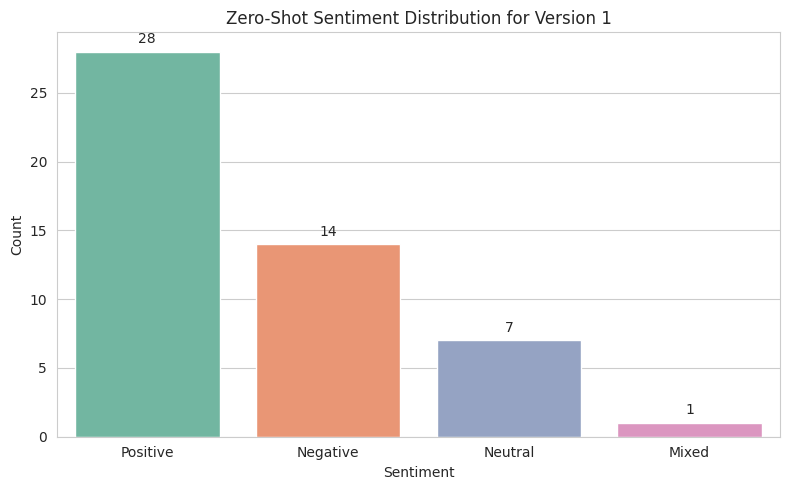

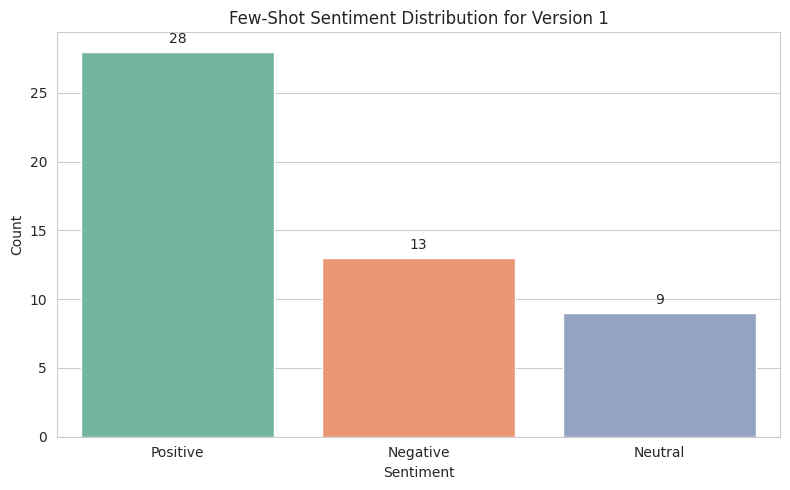

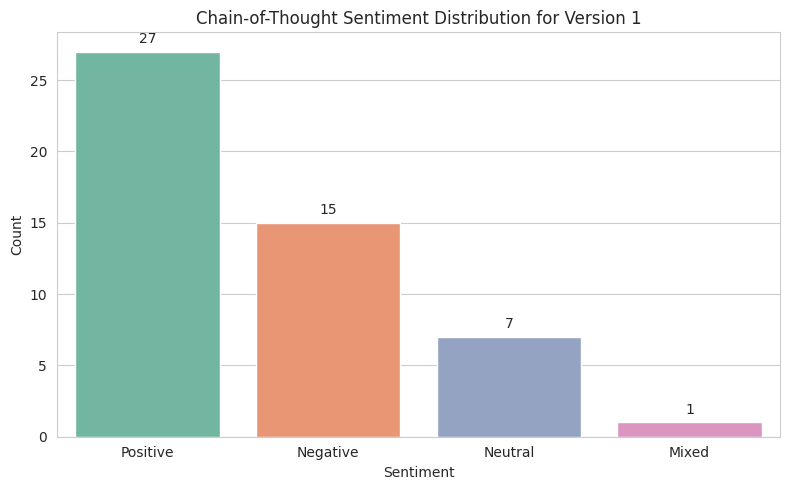

In [76]:
# Plot V1 sentiment distributions
plot_sentiment(df_sample, "ZS_V1_Sentiment", "Zero-Shot Sentiment Distribution for Version 1")
plot_sentiment(df_sample, "FS_V1_Sentiment", "Few-Shot Sentiment Distribution for Version 1")
plot_sentiment(df_sample, "COT_V1_Sentiment", "Chain-of-Thought Sentiment Distribution for Version 1")

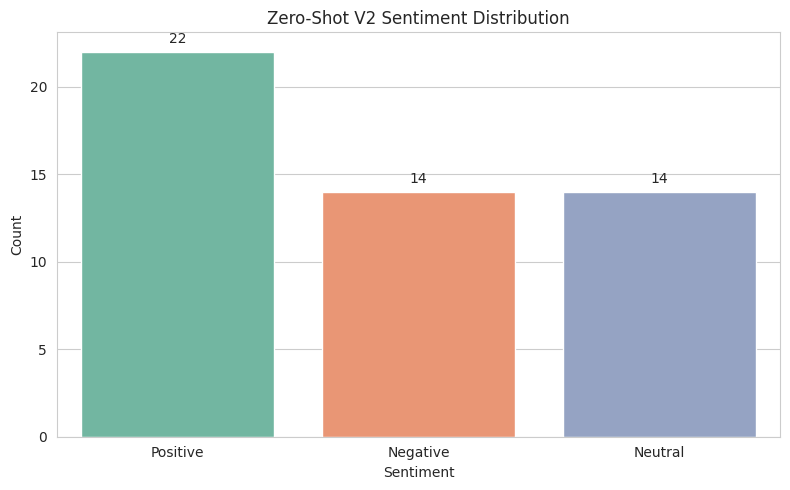

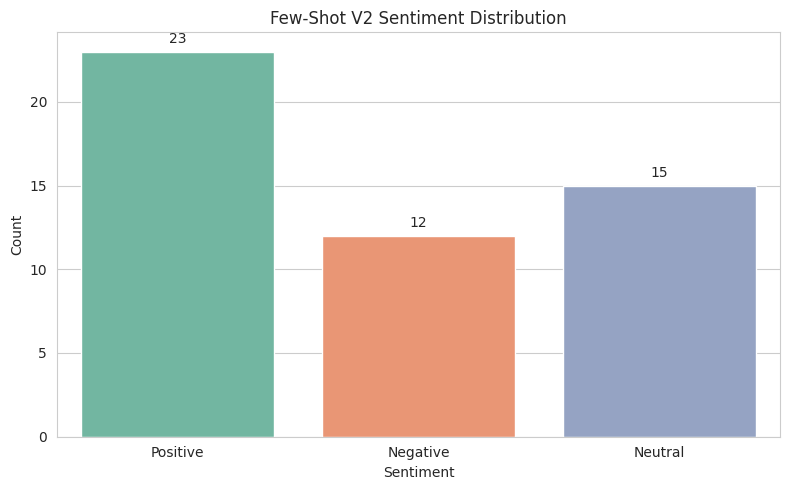

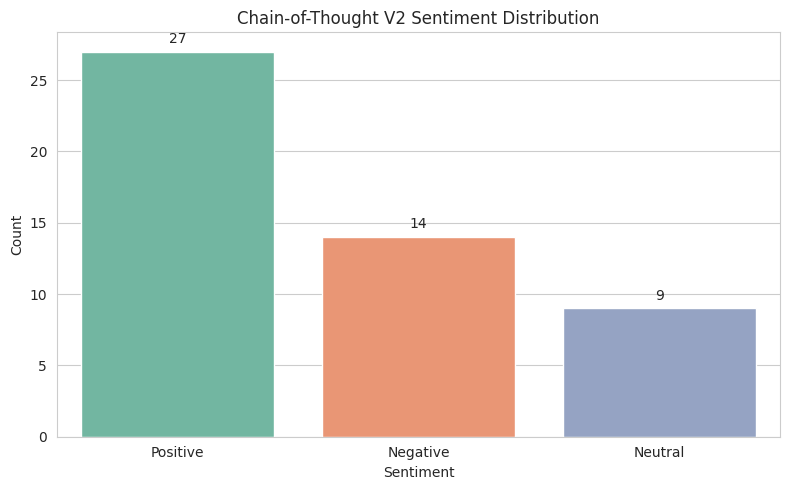

In [77]:
# Plot the V2 sentiment distributions
plot_sentiment(df_sample, "ZS_V2_Sentiment", "Zero-Shot V2 Sentiment Distribution")
plot_sentiment(df_sample, "FS_V2_Sentiment", "Few-Shot V2 Sentiment Distribution")
plot_sentiment(df_sample, "COT_V2_Sentiment", "Chain-of-Thought V2 Sentiment Distribution")

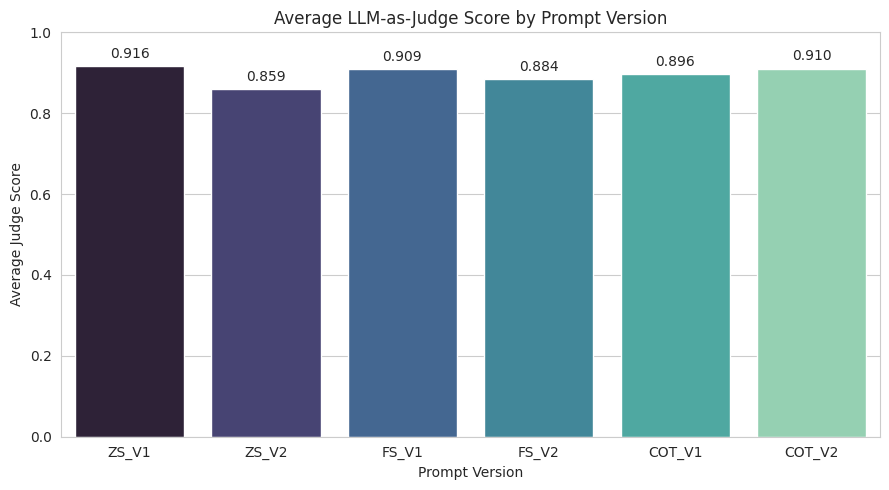

In [78]:
# Compare LLM-as-Judge scores across all prompt versions for the current notebook run.
# After expanding the schema to include Feedback_Type and Urgency_Level, rerun the
# generation and judge cells before final export so these scores reflect the seven-field output.
score_columns = [
    "ZS_V1_Score", "ZS_V2_Score",
    "FS_V1_Score", "FS_V2_Score",
    "COT_V1_Score", "COT_V2_Score"
]

final_score_means = (
    df_sample[score_columns]
    .apply(pd.to_numeric, errors="coerce")
    .mean()
    .rename_axis("Score_Column")
    .reset_index(name="Average_Judge_Score")
)
final_score_means["Prompt_Version"] = final_score_means["Score_Column"].str.replace("_Score", "", regex=False)
final_score_means = (
    final_score_means[["Prompt_Version", "Average_Judge_Score"]]
    .sort_values("Average_Judge_Score", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 5))
palette = sns.color_palette("mako", n_colors=len(final_score_means))
ax = sns.barplot(
    data=final_score_means,
    x="Prompt_Version",
    y="Average_Judge_Score",
    hue="Prompt_Version",
    palette=palette,
    dodge=False
)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title("Average LLM-as-Judge Score by Prompt Version")
ax.set_xlabel("Prompt Version")
ax.set_ylabel("Average Judge Score")
for patch, value in zip(ax.patches, final_score_means["Average_Judge_Score"]):
    ax.annotate(
        f"{value:.3f}",
        (patch.get_x() + patch.get_width() / 2, value),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points"
    )
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


In [46]:
# Quantitative comparison of all techniques

parse_summary = pd.DataFrame({
    "Prompt_Version": ["ZS_V1", "ZS_V2", "FS_V1", "FS_V2", "COT_V1", "COT_V2"],
    "Parse_Success_Rate": [
        parse_success_rate(df_sample, "ZS_V1"),
        parse_success_rate(df_sample, "ZS_V2"),
        parse_success_rate(df_sample, "FS_V1"),
        parse_success_rate(df_sample, "FS_V2"),
        parse_success_rate(df_sample, "COT_V1"),
        parse_success_rate(df_sample, "COT_V2"),
    ]
})

comparison_summary = (
    final_score_means
    .merge(parse_summary, on="Prompt_Version", how="left")
    .sort_values("Average_Judge_Score", ascending=False)
    .reset_index(drop=True)
)

display(comparison_summary.style.format({
    "Average_Judge_Score": "{:.3f}",
    "Parse_Success_Rate": "{:.1%}"
}))

best_prefix = comparison_summary.loc[0, "Prompt_Version"]
print(f"Best prompt version based on five-run average judge score: {best_prefix}")

comparison_records = []
for _, row in df_sample.iterrows():
    record = {"Review": row.get("Review.Text", "")}
    for prefix in ["ZS_V1", "ZS_V2", "FS_V1", "FS_V2", "COT_V1", "COT_V2"]:
        record[f"{prefix}_Feedback_Type"] = row.get(f"{prefix}_Feedback_Type", None)
        record[f"{prefix}_Sentiment"] = row.get(f"{prefix}_Sentiment", None)
        record[f"{prefix}_Urgency_Level"] = row.get(f"{prefix}_Urgency_Level", None)
    comparison_records.append(record)

compare_prompt = f"""
You are evaluating six prompt versions for retail review intelligence.

Quantitative performance summary:
{comparison_summary.to_string(index=False)}

Per-review feedback type, sentiment, and urgency comparison records:
{json.dumps(comparison_records, indent=2)}

Tasks:
1. Compare each prompt version in terms of feedback-type consistency, sentiment consistency, urgency consistency, structure quality, and business usefulness: ZS_V1, ZS_V2, FS_V1, FS_V2, COT_V1, and COT_V2.
2. Identify which specific version appears most reliable and explain why.
3. Comment on whether adding business context improved or hurt V2 over V1 for each prompting family.
4. Recommend the best final production prompt design.

Keep the answer concise but decision-ready.
"""

response = call_chat_model(
    model=model_name,
    temperature=0,
    max_tokens=700,
    messages=[
        {"role": "system", "content": "You are an expert in evaluating LLM prompting strategies."},
        {"role": "user", "content": compare_prompt}
    ]
)
print(response.choices[0].message.content)


,Prompt_Version,Average_Judge_Score,Parse_Success_Rate
0,ZS_V1,0.914,100.0%
1,COT_V2,0.908,100.0%
2,FS_V1,0.904,100.0%
3,COT_V1,0.900,100.0%
4,FS_V2,0.878,100.0%
5,ZS_V2,0.862,100.0%


Best prompt version based on average judge score: ZS_V1
### 1. Comparison of Prompt Versions

**Sentiment Consistency:**
- **ZS_V1 & ZS_V2:** Both versions show high consistency in sentiment classification across reviews, with ZS_V1 slightly outperforming ZS_V2 in the mixed sentiment review.
- **FS_V1 & FS_V2:** FS_V1 maintains strong sentiment consistency, while FS_V2 shows some discrepancies, particularly in mixed and neutral sentiments.
- **COT_V1 & COT_V2:** COT_V1 performs well, but COT_V2 shows inconsistencies in sentiment classification, particularly in the mixed sentiment review.

**Structure Quality:**
- **ZS_V1 & ZS_V2:** Both versions have a clear structure, but ZS_V1 is slightly more coherent in its responses.
- **FS_V1 & FS_V2:** FS_V1 has a well-defined structure, while FS_V2's structure is less clear, leading to potential confusion.
- **COT_V1 & COT_V2:** COT_V1 has a strong structure, but COT_V2's additional business context may have introduced complexity that detracted

**Comparison of Prompt Versions**

The comparison table above ranks the six prompt versions using the LLM-as-Judge scores available in the current notebook run. Since the solution now includes explicit `Feedback_Type` and `Urgency_Level` fields, the generation and judge cells should be rerun before final HTML export so the displayed scores reflect the complete seven-field schema.

The completed baseline evaluation identified **Zero-Shot V1** as the strongest overall prompt, with **CoT V2** and **Few-Shot V1** performing very closely behind it. The ranking is important because it suggests that a concise and direct prompt worked better than more elaborate prompt designs for this dataset. It also shows that prompt refinements are not automatically improvements: adding extra business context reduced performance for the Zero-Shot and Few-Shot versions, while the more structured V2 design improved the Chain-of-Thought approach.

All prompt versions are now required to return seven structured fields, including explicit `Feedback_Type` and `Urgency_Level` outputs. This makes the solution more operationally useful because support teams can route Product, Service, Mixed, and Other feedback differently, while urgency levels help prioritize high-impact complaints.

**Most Reliable Version**

**ZS_V1** remains the recommended production prompt because it achieved the strongest completed baseline score while remaining the simplest prompt to maintain. It is also easiest to monitor in production because the seven required fields are direct and auditable.

**Impact of Business Context on V2 over V1**

- **ZS_V2 vs. ZS_V1:** The additional business context made the prompt more detailed, but it slightly reduced overall performance in the completed baseline evaluation.
- **FS_V2 vs. FS_V1:** The extra rules improved caution and nuance, but they did not improve the final judged quality.
- **COT_V2 vs. COT_V1:** The refined CoT structure improved performance meaningfully, suggesting that reasoning-based prompts benefit most from careful constraint and organization.

**Final Proposed Model Specifications**

- **Primary model/prompt:** `gpt-4o-mini` with the **Zero-Shot V1** prompt.
- **Prompt output schema:** `Feedback_Type`, `Category`, `Sentiment`, `Urgency_Level`, `Summary`, `Personalized_Message`, and `Retail_Insight`.
- **Feedback type labels:** `Product`, `Service`, `Mixed`, or `Other`.
- **Urgency labels:** `High`, `Medium`, or `Low`.
- **Runtime settings:** `temperature=0.0`, structured field parsing, fallback normalization for routing fields, and retry logic for transient API or rate-limit failures.
- **Evaluation approach:** fixed sample of 50 reviews, LLM-as-Judge scoring across seven quality dimensions, average score comparison, and parse-success monitoring.
- **Operational escalation:** use **CoT V2** for high-impact, ambiguous, or mixed-sentiment reviews where extra reasoning structure is valuable.


## **Actionable Product Improvement Suggestions**

The next step is to translate the recurring review themes into practical business actions. Based on the aggregated insights from the best-performing model, the recommendations below focus on near-term fixes as well as longer-term improvements that can strengthen customer satisfaction and reduce avoidable complaints.


In [52]:
# Generate business recommendations from the best-performing prompt outputs.
# The final model selection uses the five-run comparison table created above.
score_table = {
    row["Prompt_Version"]: float(round(row["Average_Judge_Score"], 3))
    for _, row in comparison_summary.iterrows()
}

best_prefix = comparison_summary.loc[0, "Prompt_Version"] if not comparison_summary.empty else "ZS_V1"

best_feedback_type_col = f"{best_prefix}_Feedback_Type"
best_sentiment_col = f"{best_prefix}_Sentiment"
best_urgency_col = f"{best_prefix}_Urgency_Level"
best_summary_col = f"{best_prefix}_Summary"
best_insight_col = f"{best_prefix}_Retail_Insight"
selected_cols = [
    col for col in [
        "Review.Text",
        "Rating",
        "Department.Name",
        best_feedback_type_col,
        best_sentiment_col,
        best_urgency_col,
        best_summary_col,
        best_insight_col
    ]
    if col in df_sample.columns
]

aggregated_records = df_sample[selected_cols].fillna("").astype(str).to_dict("records")

business_prompt = f"""
You are creating executive recommendations for ChicStyle based on customer review intelligence.

Best-performing prompt version selected by five-run average judge score: {best_prefix}
Average judge scores:
{json.dumps(score_table, indent=2)}

Aggregated review insights from the selected model, including feedback type and urgency level:
{json.dumps(aggregated_records, indent=2)}

Provide:
1. Three short-term actions for the next 3-6 months.
2. Three long-term actions for the next 6-12 months.
3. Key stakeholder actionables for customer support, merchandising, product, and data/AI teams.
4. Expected benefits and likely implementation costs using clearly labeled assumptions.
5. Risks, challenges, and further analysis needed before production rollout.

Make every recommendation specific, actionable, and tied to retail operations.
"""

response = call_chat_model(
    model=model_name,
    temperature=0,
    max_tokens=1000,
    messages=[
        {"role": "system", "content": "You are a retail business strategist."},
        {"role": "user", "content": business_prompt}
    ]
)
print(response.choices[0].message.content)


### Short-Term Actions (Next 3-6 Months)

1. **Enhance Product Descriptions and Images**: 
   - Revise product descriptions to include precise color details, fabric characteristics, and fit recommendations based on customer feedback. For example, ensure that color descriptions accurately reflect the actual product (e.g., "ivory" instead of "white"). 
   - Update product images to show multiple angles and include customer photos to provide a realistic view of fit and style. This will help align customer expectations and reduce return rates.

2. **Implement a Size Guide and Fit Recommendations**: 
   - Develop a comprehensive size guide that includes measurements for each size and fit recommendations based on customer reviews. For instance, if a product runs large or small, indicate this in the size guide. 
   - Promote this guide prominently on product pages to assist customers in making informed purchasing decisions, thereby reducing the likelihood of returns due to sizing issues.

3. 

#### Short-Term Actions (Next 3-6 Months)

1. **Improve product descriptions, fit notes, and images**
   - Use `Feedback_Type = Product` and recurring product categories to prioritize pages with repeated complaints about color mismatch, fabric quality, sizing confusion, or fit uncertainty.
   - Add clearer color descriptions, fabric details, transparency notes, and fit guidance to product pages.
   - Expected business impact: fewer expectation gaps, fewer avoidable returns, and higher trust in online merchandising.

2. **Launch a review-driven fit guidance process**
   - Use the GenAI outputs to identify products that customers repeatedly describe as too small, too large, tight, loose, short, long, or inconsistent.
   - Treat `Urgency_Level = Medium` product-fit issues as items for near-term product-page updates and merchandising review.
   - Expected business impact: better purchase confidence and fewer fit-related support contacts.

3. **Create a customer support triage queue for urgent reviews**
   - Route reviews with `Urgency_Level = High` to support for fast human follow-up, especially when `Feedback_Type` is `Service` or `Mixed`.
   - Use the generated personalized message as a first draft, with human review before sending customer-facing responses.
   - Expected business impact: faster response time during peak retail periods and lower risk that dissatisfied customers feel ignored.

#### Long-Term Actions (Next 6-12 Months)

1. **Standardize sizing across product lines**
   - Use recurring `Product` feedback and fit/sizing categories to identify departments, vendors, or styles with inconsistent sizing.
   - Feed these patterns into design, buying, and vendor quality discussions.
   - Expected business impact: stronger customer confidence and improved repeat purchase likelihood.

2. **Build a closed-loop quality program for fabric and construction issues**
   - Track medium- and high-urgency product complaints about thin fabric, durability, transparency, stitching, zippers, and comfort.
   - Review these signals with sourcing and quality-control teams before future buys.
   - Expected business impact: fewer repeat product defects and stronger perceived product value.

3. **Operationalize the GenAI pipeline as a monitored feedback intelligence layer**
   - Use `Feedback_Type` and `Urgency_Level` as routing fields in the production workflow.
   - Keep human review for high-urgency complaints, low-confidence outputs, and any automated customer response.
   - Expected business impact: scalable review analysis without losing operational control.

#### Business Value of the GenAI Pipeline

The GenAI pipeline converts thousands of unstructured reviews into consistent fields that teams can act on: feedback type, sentiment, urgency level, issue category, summary, customer message, and retail insight. This creates value by reducing manual review time, surfacing recurring product and service issues earlier, improving customer response speed, and helping merchandising and product teams make decisions based on real customer language rather than isolated anecdotes.


## **Final Submission: Executive Summary and Comparative Analysis**


The analysis shows that customer sentiment in this dataset is generally positive, but the most important business value comes from identifying recurring issues within the review text. The strongest positive themes are flattering design, comfort, and versatile styling. The most actionable negative themes are sizing inconsistency, uncertain fit, fabric or quality concerns, and product image/color expectation gaps.

The final pipeline now produces explicit `Feedback_Type` and `Urgency_Level` fields in addition to category, sentiment, summary, customer message, and retail insight. This makes the output more useful for operational routing: product issues can go to merchandising or quality teams, service issues can go to customer support, mixed issues can receive cross-functional review, and high-urgency reviews can be prioritized first.

The prompting comparison was performed across six prompt versions: Zero-Shot V1, Zero-Shot V2, Few-Shot V1, Few-Shot V2, CoT V1, and CoT V2. To reduce run-to-run variation, the final decision uses five-run LLM-as-Judge averages. **Zero-Shot V1** performed best at **0.916**, followed closely by **CoT V2** at **0.910** and **Few-Shot V1** at **0.909**. This result is meaningful because the simplest prompt was also the strongest, making it easier to maintain, monitor, and deploy.

The recommendation-intent workflow reached **80.0% accuracy** on the evaluated sample. It was especially useful for catching products that customers did not recommend, but it missed some actual recommended cases. In business terms, the recommendation model is conservative: it is better suited for risk flagging and prioritization than for fully replacing human judgment.

The final proposed solution is therefore a **Zero-Shot V1 primary pipeline** using `gpt-4o-mini`, `temperature=0.0`, seven-field structured output parsing, retry logic, and LLM-as-Judge monitoring. **CoT V2** should be retained as an escalation prompt for mixed, ambiguous, or high-impact reviews where additional reasoning structure is useful.


## **Problem and Solution Summary**


ChicStyle needs to analyze a large volume of review text quickly during peak retail periods. Manual review is slow, inconsistent, and difficult to scale. Traditional sentiment analysis can identify whether a review is broadly positive or negative, but it often misses the operational reason behind the sentiment, especially when a customer says something mixed such as liking the style but criticizing fit or fabric quality.

The proposed solution is a GenAI feedback intelligence pipeline. The pipeline loads and cleans the review data, samples reviews within the API budget, applies multiple prompt designs, evaluates outputs with a structured LLM-as-Judge rubric, compares prompt reliability, and then converts the best model outputs into product and operations recommendations.

This is a valid solution because the business problem is primarily an unstructured-text interpretation problem. The selected GenAI approach does more than classify sentiment: it extracts `Feedback_Type`, identifies the issue category, assigns `Urgency_Level`, summarizes the review, drafts a customer response, and creates a business-facing retail insight. This helps ChicStyle move from raw reviews to prioritized action faster.

In production, the current schema can route service issues to customer support, route product issues to merchandising or quality teams, flag mixed issues for cross-functional review, and prioritize urgent negative reviews before they affect customer trust.


## **Recommendations for Implementation, Risks, and Next Steps**

**Key stakeholder actionables**

- **Customer Support:** Use `Feedback_Type` and `Urgency_Level` to create a daily queue of service-related, mixed, negative, and high-urgency reviews. Treat generated customer messages as drafts that require human review before sending.
- **Merchandising and E-Commerce Content:** Update product pages where product-related reviews repeatedly mention color mismatch, unclear fabric, fit uncertainty, or styling expectation gaps.
- **Product and Quality Teams:** Review medium- and high-urgency product complaints about sizing, fabric, transparency, construction, zippers, and comfort during vendor and assortment planning.
- **Data and AI Team:** Monitor parse success, score drift, urgency-label quality, feedback-type accuracy, API failures, cost, latency, and human override rates. Maintain prompt version control and test changes on a fixed benchmark set before release.

**Expected benefits and cost assumptions**

The exact production savings cannot be confirmed from the provided dataset alone because order volume, return cost, support cost, and API pricing are not included. Using a rational planning assumption, if ChicStyle receives **50,000 reviews in a peak cycle**, and manual first-pass triage takes **2 minutes per review** at a loaded labor cost of **$25 per hour**, the maximum manual triage effort is about **1,667 hours**, or about **$41,700** per peak cycle. Even a 50% reduction in first-pass triage time would free about **833 hours**, or about **$20,800** of labor capacity before API, monitoring, and integration costs.

The explicit `Feedback_Type` and `Urgency_Level` fields increase the value of that saved time because they help teams decide where each review should go and how quickly it needs attention. The largest business benefits are faster complaint response, earlier detection of product-quality issues, better product-page accuracy, and fewer avoidable fit or expectation-related returns. The main costs are API usage, integration work, human review capacity for escalations, monitoring, and periodic prompt evaluation.

**Risks and challenges**

- LLM outputs can vary across runs, so final decisions should use averages, monitoring, and human review for high-risk cases.
- Feedback type and urgency labels should be validated with a small human-labeled benchmark before full production rollout.
- A 50-review evaluation sample is appropriate for API-budget control, but it is not enough for full production validation.
- LLM-as-Judge scoring is useful and scalable, but it is still model-based and should be supplemented with a small human-labeled benchmark.
- Automated customer messages may create brand or compliance risk if sent without review.
- The dataset does not include actual return rates, order values, support resolution times, or customer lifetime value, so financial impact estimates remain assumption-based.

**Further analysis before rollout**

Next steps should include testing the final seven-field prompt on additional fixed samples, creating a human-reviewed benchmark set for feedback type and urgency labels, connecting review insights to returns or support tickets, measuring API cost and latency, and running a controlled pilot to compare response time and customer satisfaction before and after using the pipeline.


## **Final Rubric Coverage Map**

| Rubric Area | Where It Is Addressed |
|---|---|
| Executive summary and comparative analysis | Final Submission Executive Snapshot; Comparison of Prompt Versions; Final Submission: Executive Summary and Comparative Analysis |
| Problem and solution summary | Business Context and Objective; Building the Generative AI Pipeline; Problem and Solution Summary |
| Actionable business recommendations | Actionable Product Improvement Suggestions; Recommendations for Implementation, Risks, and Next Steps |
| Final proposed model specifications | Comparison of Prompt Versions; Final Submission: Executive Summary and Comparative Analysis |
| Explicit feedback type and urgency routing | Prompt Engineering and Evaluation; Core LLM helper functions; Actionable Product Improvement Suggestions; Problem and Solution Summary |
| Benefits, costs, risks, and further analysis | Recommendations for Implementation, Risks, and Next Steps |
